#584 Project - Walmart Retail Analytics - Predicting Product Performance

For this project, we use the “Walmart Recruiting – Store Sales Forecasting” dataset from Kaggle, which contains historical weekly sales for 45 US Walmart stores at the store–department level from February 2010 to November 2012. The data is split across three main files: train.csv (≈422K rows of Weekly_Sales by Store–Dept–Date with holiday flags), features.csv (store-level economic, promotional, and seasonal covariates such as temperature, fuel price, markdowns, CPI, unemployment, and holiday indicators), and stores.csv (store type and size).

We integrate these sources in PySpark into a single analytics table, which serves as the foundation for forecasting weekly sales and profiling department-level product performance. While the public dataset is moderate in size, **our data model, partitioning strategy, and Spark-based pipeline are explicitly designed to scale to production-level Walmart data volumes.**

Files Used:

train.csv: ~421,570 rows – Store, Dept, Date, Weekly_Sales, IsHoliday

features.csv: ~8,190 rows – Store, Date, Temperature, Fuel_Price, MarkDown1–5, CPI, Unemployment, IsHoliday

stores.csv: 45 rows – Store, Type, Size

##Part 1: Creating a master dataframe in pyspark from the external data source

### Creating PySpark environment

In [1]:
!pip install pyspark

In [2]:
import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-8-openjdk-amd64'
!java -version

openjdk version "17.0.16" 2025-07-15
OpenJDK Runtime Environment (build 17.0.16+8-Ubuntu-0ubuntu122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.16+8-Ubuntu-0ubuntu122.04.1, mixed mode, sharing)


In [3]:
!apt-get update
!apt-get install -y openjdk-11-jdk-headless
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'
!java -version

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,160 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.6 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/u

In [4]:
# Creating PySpark session application
from pyspark.sql import SparkSession
spark = (SparkSession.builder.\
         appName("Walmart_Retail_Analytics").\
         getOrCreate())

### Importing external data into pyspark dataframe

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# ─────────────────────────────────────────────
#### UPDATE THESE PATHS to match your Google Drive folder structure
#### Example: "/content/drive/MyDrive/YourFolderName/train.csv"
# ─────────────────────────────────────────────
DATA_PATH = "/content/drive/MyDrive/..."

train_df = spark.read.option("header", "true").option("inferSchema", "true").csv(f"{DATA_PATH}/train.csv")
features_df = spark.read.option("header", "true").option("inferSchema", "true").csv(f"{DATA_PATH}/features.csv")
stores_df = spark.read.option("header", "true").option("inferSchema", "true").csv(f"{DATA_PATH}/stores.csv")

In [ ]:
# Data Path Update:
DATA_PATH = "/content/drive/MyDrive/..."

###1. storing train.csv data into train_df

train_df = (spark.read.option("header", "true")\
            .option("inferSchema", "true")\
            .csv(f"{DATA_PATH}/train.csv"))
  # Print df information
train_df.show(5)

train_columns = len(train_df.columns)
print(f"Number of coulmns in train_df: {train_columns}")

train_rows = train_df.count()
print(f"Number of rows in train_df: {train_rows}")
print()


###2. storing features.csv data into features_df

features_df = (spark.read.option("header", "true")\
            .option("inferSchema", "true")\
            .csv(f"{DATA_PATH}/features.csv"))
  # Print df information
features_df.show(5)

features_columns = len(features_df.columns)
print(f"Number of coulmns in features_df: {features_columns}")

features_rows = features_df.count()
print(f"Number of rows in features_df: {features_rows}")
print()


###3. storing stores.csv data into stores_df

stores_df = (spark.read.option("header", "true")\
            .option("inferSchema", "true")\
            .csv(f"{DATA_PATH}/stores.csv"))
  # Print df information
stores_df.show(5)

stores_columns = len(stores_df.columns)
print(f"Number of coulmns in stores_df: {stores_columns}")

stores_rows = stores_df.count()
print(f"Number of rows in stores_df: {stores_rows}")

+-----+----+----------+------------+---------+
|Store|Dept|      Date|Weekly_Sales|IsHoliday|
+-----+----+----------+------------+---------+
|    1|   1|2010-02-05|     24924.5|    false|
|    1|   1|2010-02-12|    46039.49|     true|
|    1|   1|2010-02-19|    41595.55|    false|
|    1|   1|2010-02-26|    19403.54|    false|
|    1|   1|2010-03-05|     21827.9|    false|
+-----+----+----------+------------+---------+
only showing top 5 rows

Number of coulmns in train_df: 5
Number of rows in train_df: 421570

+-----+----------+-----------+----------+---------+---------+---------+---------+---------+-----------+------------+---------+
|Store|      Date|Temperature|Fuel_Price|MarkDown1|MarkDown2|MarkDown3|MarkDown4|MarkDown5|        CPI|Unemployment|IsHoliday|
+-----+----------+-----------+----------+---------+---------+---------+---------+---------+-----------+------------+---------+
|    1|2010-02-05|      42.31|     2.572|       NA|       NA|       NA|       NA|       NA|211.0963582

### Combining train, features and stores dataframes to create a master dataframe for analysis

In [7]:
##Combining Datasets imported
master_df = (train_df
           .join(stores_df, on="Store", how="left")
           .join(features_df, on=["Store", "Date"], how="left"))

##Using master_df as a master dataset
master_df.printSchema()
master_df.show(10)

print("Rows in master_df:", master_df.count())

num_columns = len(master_df.columns)
print(f"Columns in master_df: {num_columns}")

root
 |-- Store: integer (nullable = true)
 |-- Date: date (nullable = true)
 |-- Dept: integer (nullable = true)
 |-- Weekly_Sales: double (nullable = true)
 |-- IsHoliday: boolean (nullable = true)
 |-- Type: string (nullable = true)
 |-- Size: integer (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Fuel_Price: double (nullable = true)
 |-- MarkDown1: string (nullable = true)
 |-- MarkDown2: string (nullable = true)
 |-- MarkDown3: string (nullable = true)
 |-- MarkDown4: string (nullable = true)
 |-- MarkDown5: string (nullable = true)
 |-- CPI: string (nullable = true)
 |-- Unemployment: string (nullable = true)
 |-- IsHoliday: boolean (nullable = true)

+-----+----------+----+------------+---------+----+------+-----------+----------+---------+---------+---------+---------+---------+-----------+------------+---------+
|Store|      Date|Dept|Weekly_Sales|IsHoliday|Type|  Size|Temperature|Fuel_Price|MarkDown1|MarkDown2|MarkDown3|MarkDown4|MarkDown5|        CPI|Unemp

##Part 2: Performing sanity checks and Exploratory Data Analysis (EDA)

### Dataframe cleaning and structuing

In master_df dataframe we observe that 'IsHoliday' column appears twice from train and features df. We need to keep either of them to avoid future duplicate errors. We also observe that some numeric columns datatype is changed to string, we need to change it to correct datatype (numeric).

We'll complete this in 2 sections:
1. Keeping one holiday column and setting it to Boolean Datatype
2. Reverting datatypes of string datatype columns to numeric

#### Step 1.1 : Rename duplicate columns by position

In [23]:
cols = master_df.columns

seen = {}
new_cols = []

for name in cols:
    if name not in seen:
        seen[name] = 1
        new_cols.append(name)
    else:
        # create a unique name for duplicate
        new_name = f"{name}_{seen[name]}"
        seen[name] += 1
        new_cols.append(new_name)

# Rename columns by position in one shot
master_df = master_df.toDF(*new_cols)

print(master_df.columns)


['Store', 'Date', 'Dept', 'Weekly_Sales', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday', 'Year', 'Month', 'WeekOfYear', 'Weekly_Sales_lag1', 'Weekly_Sales_lag2', 'Weekly_Sales_MA4']


#### Step 1.2 : Merge the two IsHoliday columns & drop the extra

In [24]:
from pyspark.sql.functions import coalesce, col

if "IsHoliday_1" in master_df.columns:
    master_df = (master_df
        .withColumn(
            "IsHoliday_clean",
            coalesce(col("IsHoliday"), col("IsHoliday_1")).cast("boolean")
        )
        .drop("IsHoliday", "IsHoliday_1")
        .withColumnRenamed("IsHoliday_clean", "IsHoliday")
    )
else:
    # Fallback: ensure IsHoliday is boolean
    master_df = master_df.withColumn("IsHoliday", col("IsHoliday").cast("boolean"))

master_df.printSchema()
print(master_df.columns)


root
 |-- Store: integer (nullable = true)
 |-- Date: date (nullable = true)
 |-- Dept: integer (nullable = true)
 |-- Weekly_Sales: double (nullable = true)
 |-- Type: string (nullable = true)
 |-- Size: integer (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Fuel_Price: double (nullable = true)
 |-- MarkDown1: double (nullable = false)
 |-- MarkDown2: double (nullable = false)
 |-- MarkDown3: double (nullable = false)
 |-- MarkDown4: double (nullable = false)
 |-- MarkDown5: double (nullable = false)
 |-- CPI: double (nullable = true)
 |-- Unemployment: double (nullable = true)
 |-- IsHoliday: boolean (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- WeekOfYear: integer (nullable = true)
 |-- Weekly_Sales_lag1: double (nullable = true)
 |-- Weekly_Sales_lag2: double (nullable = true)
 |-- Weekly_Sales_MA4: double (nullable = true)

['Store', 'Date', 'Dept', 'Weekly_Sales', 'Type', 'Size', 'Temperature', 'Fuel_Price', '

#### Step 2 : Fix numeric columns

In [25]:
from pyspark.sql.functions import col

to_double = [
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "CPI", "Unemployment"
]

for c in to_double:
    if c in master_df.columns:
        master_df = master_df.withColumn(c, col(c).cast("double"))

master_df.printSchema()
master_df.show(5)

root
 |-- Store: integer (nullable = true)
 |-- Date: date (nullable = true)
 |-- Dept: integer (nullable = true)
 |-- Weekly_Sales: double (nullable = true)
 |-- Type: string (nullable = true)
 |-- Size: integer (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Fuel_Price: double (nullable = true)
 |-- MarkDown1: double (nullable = false)
 |-- MarkDown2: double (nullable = false)
 |-- MarkDown3: double (nullable = false)
 |-- MarkDown4: double (nullable = false)
 |-- MarkDown5: double (nullable = false)
 |-- CPI: double (nullable = true)
 |-- Unemployment: double (nullable = true)
 |-- IsHoliday: boolean (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- WeekOfYear: integer (nullable = true)
 |-- Weekly_Sales_lag1: double (nullable = true)
 |-- Weekly_Sales_lag2: double (nullable = true)
 |-- Weekly_Sales_MA4: double (nullable = true)

+-----+----------+----+------------+----+------+-----------+----------+---------+-------

#### Step 3 : Check the master_df for any other clean-ups

In [26]:
from pyspark.sql.functions import min as _min, max as _max, count as _count, sum as _sum, when

print("Rows:", master_df.count())
master_df.select(_min("Date").alias("min_date"),
                 _max("Date").alias("max_date")).show()

# Nulls in key numeric cols
check_cols = ["Weekly_Sales","Temperature","Fuel_Price","CPI","Unemployment",
              "MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]
nulls = master_df.select([
    _sum(col(c).isNull().cast("int")).alias(c)
    for c in check_cols if c in master_df.columns
])
nulls.show(truncate=False)

# Uniqueness of (Store, Dept, Date)
dupes = (master_df
         .groupBy("Store", "Dept", "Date")
         .agg(_count("*").alias("row_count"))
         .filter(col("row_count") > 1))
print("Duplicate (Store,Dept,Date) rows:", dupes.count())


Rows: 421570
+----------+----------+
|  min_date|  max_date|
+----------+----------+
|2010-02-05|2012-10-26|
+----------+----------+

+------------+-----------+----------+---+------------+---------+---------+---------+---------+---------+
|Weekly_Sales|Temperature|Fuel_Price|CPI|Unemployment|MarkDown1|MarkDown2|MarkDown3|MarkDown4|MarkDown5|
+------------+-----------+----------+---+------------+---------+---------+---------+---------+---------+
|0           |0          |0         |0  |0           |0        |0        |0        |0        |0        |
+------------+-----------+----------+---+------------+---------+---------+---------+---------+---------+

Duplicate (Store,Dept,Date) rows: 0


From the above result we can conclude that our integrated master_df is structurally consistent:

no duplicate keys, complete target and core features, and missingness concentrated in markdown variables, which aligns with real-world promotional sparsity.

We profiled missing values and identified MarkDown variables as sparse; these will be handled via domain-aware imputation or treated as zero markdown when appropriate.

In [27]:
#Confirmation on null counts in master df before proceeding

null_counts = [
    _count(when(col(c).isNull(), c)).alias(c)
    for c in master_df.columns
]
master_df.agg(*null_counts).show()

+-----+----+----+------------+----+----+-----------+----------+---------+---------+---------+---------+---------+---+------------+---------+----+-----+----------+-----------------+-----------------+----------------+
|Store|Date|Dept|Weekly_Sales|Type|Size|Temperature|Fuel_Price|MarkDown1|MarkDown2|MarkDown3|MarkDown4|MarkDown5|CPI|Unemployment|IsHoliday|Year|Month|WeekOfYear|Weekly_Sales_lag1|Weekly_Sales_lag2|Weekly_Sales_MA4|
+-----+----+----+------------+----+----+-----------+----------+---------+---------+---------+---------+---------+---+------------+---------+----+-----+----------+-----------------+-----------------+----------------+
|    0|   0|   0|           0|   0|   0|          0|         0|        0|        0|        0|        0|        0|  0|           0|        0|   0|    0|         0|             3331|             6625|            3331|
+-----+----+----+------------+----+----+-----------+----------+---------+---------+---------+---------+---------+---+------------+------

### EDA

In [28]:
#### Step 1: Add core date features
from pyspark.sql.functions import year, month, weekofyear

master_df = (master_df
    .withColumn("Year", year("Date"))
    .withColumn("Month", month("Date"))
    .withColumn("WeekOfYear", weekofyear("Date"))

)

In [29]:
#### Step 2: Handle MarkDown nulls (make a clear modeling choice)
markdown_cols = ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]

for c in markdown_cols:
    if c in master_df.columns:
        master_df = master_df.fillna({c: 0.0})


In [30]:
master_df.show(5)

+-----+----------+----+------------+----+------+-----------+----------+---------+---------+---------+---------+---------+-----------+------------+---------+----+-----+----------+-----------------+-----------------+------------------+
|Store|      Date|Dept|Weekly_Sales|Type|  Size|Temperature|Fuel_Price|MarkDown1|MarkDown2|MarkDown3|MarkDown4|MarkDown5|        CPI|Unemployment|IsHoliday|Year|Month|WeekOfYear|Weekly_Sales_lag1|Weekly_Sales_lag2|  Weekly_Sales_MA4|
+-----+----------+----+------------+----+------+-----------+----------+---------+---------+---------+---------+---------+-----------+------------+---------+----+-----+----------+-----------------+-----------------+------------------+
|    1|2010-02-05|   1|     24924.5|   A|151315|      42.31|     2.572|      0.0|      0.0|      0.0|      0.0|      0.0|211.0963582|       8.106|    false|2010|    2|         5|             NULL|             NULL|              NULL|
|    1|2010-02-12|   1|    46039.49|   A|151315|      38.51|    

In [31]:
# Saving cleaned master file as CSV using Pandas.
# With PySpark, it was a long process to save as CSV since it used multiple
# worker nodes to save 2 csv files and then these 2 files needed to be merged into single file.

import pandas as pd

pandas_master_df = master_df.toPandas()
pandas_master_df.to_csv("master_data_cleaned.csv", index=False)

In [32]:
#### Step 3: Quick distribution checks (for narrative + sanity)
master_df.select("Weekly_Sales").describe().show()

q = master_df.approxQuantile("Weekly_Sales", [0.25, 0.5, 0.75, 0.95, 0.99], 0.01)
print(q)

+-------+-----------------+
|summary|     Weekly_Sales|
+-------+-----------------+
|  count|           421570|
|   mean|15981.25812346715|
| stddev|22711.18351916317|
|    min|         -4988.94|
|    max|        693099.36|
+-------+-----------------+

[2108.4, 7546.8, 20098.19, 58226.56, 693099.36]


Store and Dept performance snapshots

In [33]:
#### Step 4: Store & Dept performance snapshots

##### Store Performance

from pyspark.sql.functions import sum as _sum, avg as _avg, col, format_number

# 1) Raw numeric metrics
store_perf_raw = (master_df.groupBy("Store")
    .agg(
        _sum("Weekly_Sales").alias("total_sales"),
        _avg("Weekly_Sales").alias("avg_weekly_sales")
    )
)

# 2) Top 5 stores (numeric sort)
top5_stores = (store_perf_raw
    .orderBy(col("total_sales").desc())
    .select(
        "Store",
        format_number("total_sales", 2).alias("total_sales"),
        format_number("avg_weekly_sales", 2).alias("avg_weekly_sales")
    )
)

print("Top 5 Stores by Total Sales:")
top5_stores.show(5)

# 3) Bottom 5 stores (numeric sort)
bottom5_stores = (store_perf_raw
    .orderBy(col("total_sales").asc())
    .select(
        "Store",
        format_number("total_sales", 2).alias("total_sales"),
        format_number("avg_weekly_sales", 2).alias("avg_weekly_sales")
    )
)

print("Bottom 5 Stores by Total Sales:")
bottom5_stores.show(5)

# 4) Proper summary (on numeric)
print("Performance summary across Stores: ")

store_summary = store_perf_raw.describe(["total_sales", "avg_weekly_sales"])

store_summary = (store_summary
    .withColumn("total_sales",
                format_number(col("total_sales").cast("double"), 2))
    .withColumn("avg_weekly_sales",
                format_number(col("avg_weekly_sales").cast("double"), 2))
)

store_summary.show(truncate=False)

Top 5 Stores by Total Sales:
+-----+--------------+----------------+
|Store|   total_sales|avg_weekly_sales|
+-----+--------------+----------------+
|   20|301,397,792.46|       29,508.30|
|    4|299,543,953.38|       29,161.21|
|   14|288,999,911.34|       28,784.85|
|   13|286,517,703.80|       27,355.14|
|    2|275,382,440.98|       26,898.07|
+-----+--------------+----------------+
only showing top 5 rows

Bottom 5 Stores by Total Sales:
+-----+-------------+----------------+
|Store|  total_sales|avg_weekly_sales|
+-----+-------------+----------------+
|   33|37,160,221.96|        5,728.41|
|   44|43,293,087.84|        6,038.93|
|    5|45,475,688.90|        5,053.42|
|   36|53,412,214.97|        8,584.41|
|   38|55,159,626.42|        7,492.48|
+-----+-------------+----------------+
only showing top 5 rows

Performance summary across Stores: 
+-------+--------------+----------------+
|summary|total_sales   |avg_weekly_sales|
+-------+--------------+----------------+
|count  |45.00  

In [34]:
##### Department Performance

# 1) Raw numeric metrics
dept_perf_raw = (master_df.groupBy("Dept")
    .agg(
        _sum("Weekly_Sales").alias("total_sales"),
        _avg("Weekly_Sales").alias("avg_weekly_sales")
    )
)

# 2) Top 5 depts
top5_depts = (dept_perf_raw
    .orderBy(col("total_sales").desc())
    .select(
        "Dept",
        format_number("total_sales", 2).alias("total_sales"),
        format_number("avg_weekly_sales", 2).alias("avg_weekly_sales")
    )
)

print("Top 5 Depts by Total Sales:")
top5_depts.show(5)

# 3) Bottom 5 depts
bottom5_depts = (dept_perf_raw
    .orderBy(col("total_sales").asc())
    .select(
        "Dept",
        format_number("total_sales", 2).alias("total_sales"),
        format_number("avg_weekly_sales", 2).alias("avg_weekly_sales")
    )
)

print("Bottom 5 Depts by Total Sales:")
bottom5_depts.show(5)

# 4) Proper summary
print("Performance summary across Departments: ")

department_summary = dept_perf_raw.describe(["total_sales", "avg_weekly_sales"])

department_summary = (department_summary
    .withColumn("total_sales",
                format_number(col("total_sales").cast("double"), 2))
    .withColumn("avg_weekly_sales",
                format_number(col("avg_weekly_sales").cast("double"), 2))
)

department_summary.show(truncate=False)

Top 5 Depts by Total Sales:
+----+--------------+----------------+
|Dept|   total_sales|avg_weekly_sales|
+----+--------------+----------------+
|  92|483,943,341.87|       75,204.87|
|  95|449,320,162.52|       69,824.42|
|  38|393,118,136.92|       61,090.62|
|  72|305,725,152.21|       50,566.52|
|  90|291,068,463.68|       45,232.08|
+----+--------------+----------------+
only showing top 5 rows

Bottom 5 Depts by Total Sales:
+----+-----------+----------------+
|Dept|total_sales|avg_weekly_sales|
+----+-----------+----------------+
|  47|  -4,962.93|           -7.68|
|  43|      14.32|            1.19|
|  39|     177.98|           11.12|
|  78|   1,714.71|            7.30|
|  51|  30,572.83|           21.93|
+----+-----------+----------------+
only showing top 5 rows

Performance summary across Departments: 
+-------+--------------+----------------+
|summary|total_sales   |avg_weekly_sales|
+-------+--------------+----------------+
|count  |81.00         |81.00           |
|mean  

In [35]:
####Step 5: Holiday vs non-holiday impact
holiday_stats = (master_df.groupBy("IsHoliday")
                 .agg(_avg("Weekly_Sales").alias("avg_weekly_sales")))
holiday_stats.show()


+---------+------------------+
|IsHoliday|  avg_weekly_sales|
+---------+------------------+
|     true| 17035.82318735042|
|    false|15901.445069008467|
+---------+------------------+



In [36]:
####Step 6: Build baseline time-series features

from pyspark.sql.window import Window
from pyspark.sql.functions import lag, avg

w = Window.partitionBy("Store", "Dept").orderBy("Date")


#add lag features
master_df = (master_df
    .withColumn("Weekly_Sales_lag1", lag("Weekly_Sales", 1).over(w))
    .withColumn("Weekly_Sales_lag2", lag("Weekly_Sales", 2).over(w))
)


#add rolling mean baseline (4 weeks)
w_ma4 = w.rowsBetween(-4, -1)

master_df = master_df.withColumn(
    "Weekly_Sales_MA4",
    avg("Weekly_Sales").over(w_ma4)
)

master_df.show(10)

+-----+----------+----+------------+----+------+-----------+----------+---------+---------+---------+---------+---------+-----------+------------+---------+----+-----+----------+-----------------+-----------------+------------------+
|Store|      Date|Dept|Weekly_Sales|Type|  Size|Temperature|Fuel_Price|MarkDown1|MarkDown2|MarkDown3|MarkDown4|MarkDown5|        CPI|Unemployment|IsHoliday|Year|Month|WeekOfYear|Weekly_Sales_lag1|Weekly_Sales_lag2|  Weekly_Sales_MA4|
+-----+----------+----+------------+----+------+-----------+----------+---------+---------+---------+---------+---------+-----------+------------+---------+----+-----+----------+-----------------+-----------------+------------------+
|    1|2010-02-05|   1|     24924.5|   A|151315|      42.31|     2.572|      0.0|      0.0|      0.0|      0.0|      0.0|211.0963582|       8.106|    false|2010|    2|         5|             NULL|             NULL|              NULL|
|    1|2010-02-12|   1|    46039.49|   A|151315|      38.51|    

In [37]:
#### Step 7: Define model-ready dataframe

feature_cols = [
    "Date",
    "Weekly_Sales",
    "Store", "Dept",
    "Type", "Size",
    "IsHoliday",
    "Temperature", "Fuel_Price",
    "CPI", "Unemployment",
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "Year", "Month", "WeekOfYear",
    "Weekly_Sales_lag1", "Weekly_Sales_lag2", "Weekly_Sales_MA4"
]

model_df = master_df.select(feature_cols).na.drop(subset=["Weekly_Sales_lag1","Weekly_Sales_lag2","Weekly_Sales_MA4"])

model_df.printSchema()
print("model_df rows:", model_df.count())

root
 |-- Date: date (nullable = true)
 |-- Weekly_Sales: double (nullable = true)
 |-- Store: integer (nullable = true)
 |-- Dept: integer (nullable = true)
 |-- Type: string (nullable = true)
 |-- Size: integer (nullable = true)
 |-- IsHoliday: boolean (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Fuel_Price: double (nullable = true)
 |-- CPI: double (nullable = true)
 |-- Unemployment: double (nullable = true)
 |-- MarkDown1: double (nullable = false)
 |-- MarkDown2: double (nullable = false)
 |-- MarkDown3: double (nullable = false)
 |-- MarkDown4: double (nullable = false)
 |-- MarkDown5: double (nullable = false)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- WeekOfYear: integer (nullable = true)
 |-- Weekly_Sales_lag1: double (nullable = true)
 |-- Weekly_Sales_lag2: double (nullable = true)
 |-- Weekly_Sales_MA4: double (nullable = true)

model_df rows: 414945


## Part 3 : Visualizations

### Finding correlation between all the features

Calculating Correlation Matrix...


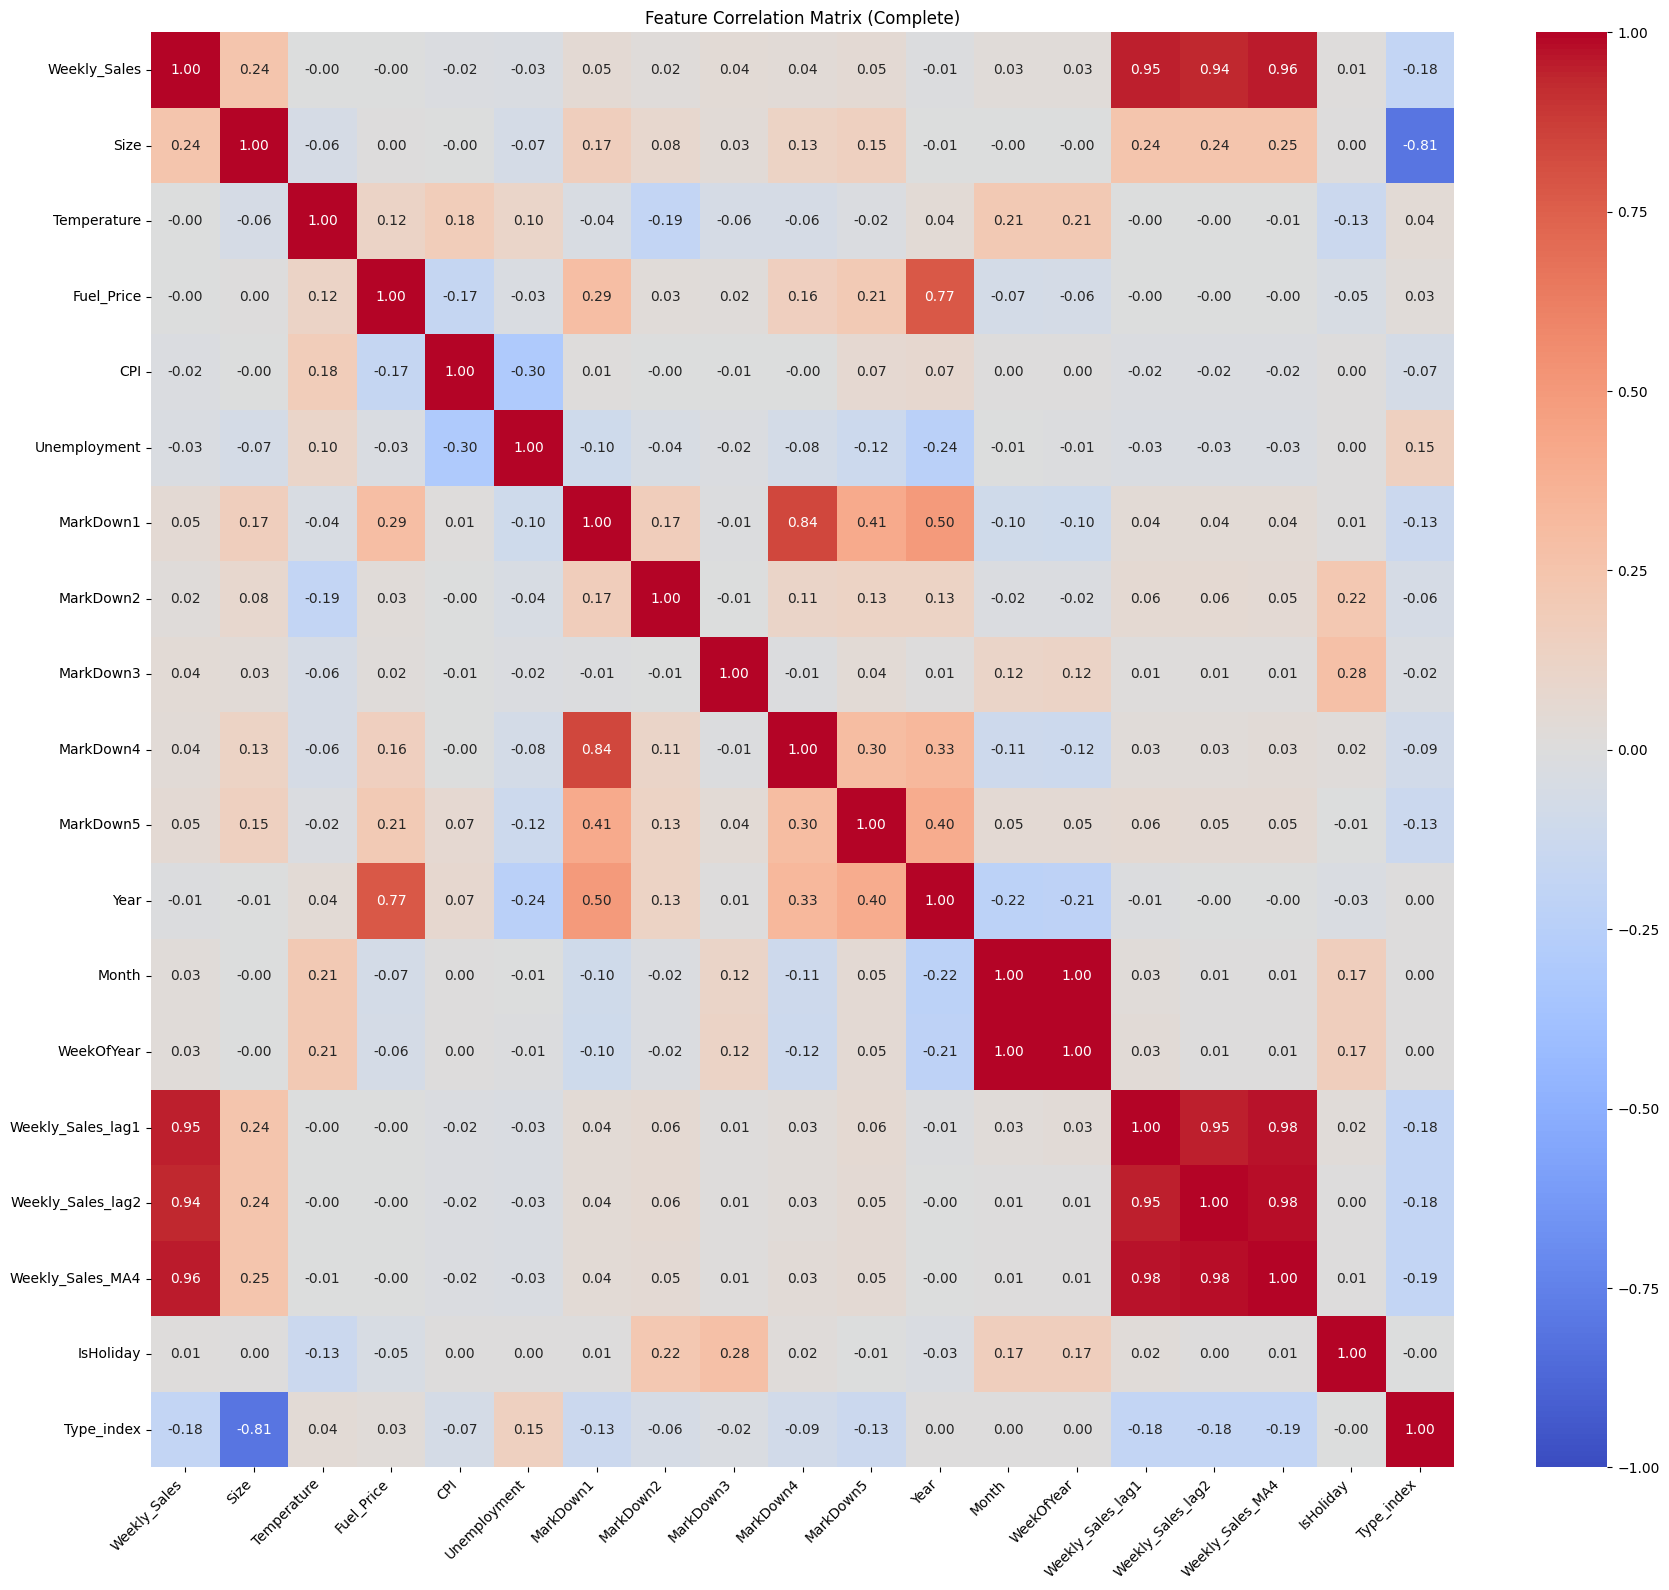

In [38]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml import Pipeline
from pyspark.sql.functions import col
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- STEP 1: DATA PREP ---
# 1. Cast IsHoliday to Integer (True=1, False=0)
# 2. Drop rows where Lags/MA are null (Essential for correlation math)
# 3. Filter out any potential nulls in feature columns to be safe
clean_corr_df = master_df.withColumn("IsHoliday", col("IsHoliday").cast("integer")) \
                         .na.drop(subset=["Weekly_Sales_lag1", "Weekly_Sales_lag2", "Weekly_Sales_MA4"])

# --- STEP 2: DEFINE COLUMNS (Aligned with your Schema) ---
cat_cols = ['Type']

# We include ALL numerical features from your schema
# Note: We EXCLUDE 'Date', 'Store', 'Dept' as they are not predictive numbers in this context
num_cols = [
    'Weekly_Sales',
    'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'Year', 'Month', 'WeekOfYear',                 # Time Features
    'Weekly_Sales_lag1', 'Weekly_Sales_lag2',      # Lags
    'Weekly_Sales_MA4',                            # Moving Average
    'IsHoliday'                                    # Converted Integer
]

# --- STEP 3: PIPELINE FOR INDEXING ---
# Convert 'Type' (A,B,C) -> 'Type_index' (0,1,2)
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid="keep")
    for c in cat_cols
]

pipeline = Pipeline(stages=indexers)
df_ready = pipeline.fit(clean_corr_df).transform(clean_corr_df)

# --- STEP 4: VECTOR ASSEMBLY ---
# Combine all numeric cols + the new 'Type_index'
all_features = num_cols + [f"{c}_index" for c in cat_cols]

assembler = VectorAssembler(
    inputCols=all_features,
    outputCol="corr_features",
    handleInvalid="skip"
)

df_vector = assembler.transform(df_ready).select("corr_features")

# --- STEP 5: CALCULATE MATRIX ---
print("Calculating Correlation Matrix...")
matrix = Correlation.corr(df_vector, "corr_features").head()
corr_array = matrix[0].toArray()

# --- STEP 6: PLOT (Pandas) ---
pdf_corr = pd.DataFrame(corr_array, columns=all_features, index=all_features)

plt.figure(figsize=(18, 16)) # Large size to fit all labels
sns.heatmap(pdf_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix (Complete)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 1. Overall Weekly Sales Trend (Time-Series Line Plot)

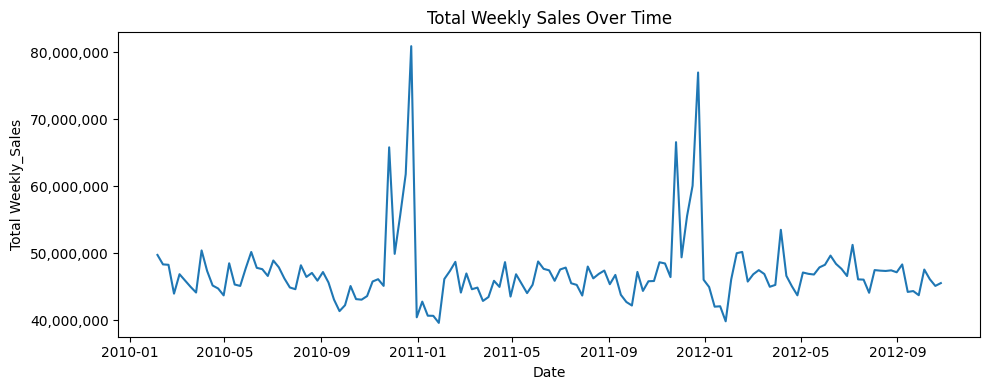

In [39]:
from pyspark.sql.functions import sum as _sum
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick # Import for formatting

# Aggregate weekly total sales
weekly_trend = (master_df
    .groupBy("Date")
    .agg(_sum("Weekly_Sales").alias("total_sales"))
    .orderBy("Date"))

pdf_weekly = weekly_trend.toPandas()

plt.figure(figsize=(10, 4))
plt.plot(pdf_weekly["Date"], pdf_weekly["total_sales"])
plt.xlabel("Date")
plt.ylabel("Total Weekly_Sales")
plt.title("Total Weekly Sales Over Time")

# Get the current axes
ax = plt.gca()
# Format y-axis labels to avoid scientific notation and add comma separators
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

### 2. Top 10 Stores by Total Sales (Bar Chart)

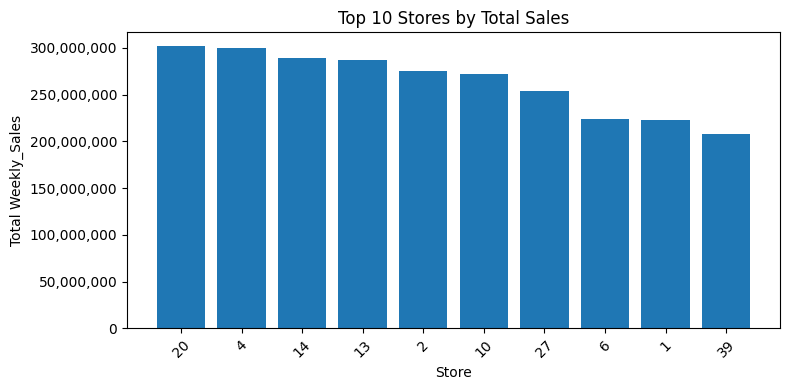

In [40]:
from pyspark.sql.functions import sum as _sum
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

store_perf_raw = (master_df.groupBy("Store")
    .agg(_sum("Weekly_Sales").alias("total_sales")))

top10_stores_df = (store_perf_raw
    .orderBy("total_sales", ascending=False)
    .limit(10)
    .toPandas())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(top10_stores_df["Store"].astype(str), top10_stores_df["total_sales"])
ax.set_xlabel("Store")
ax.set_ylabel("Total Weekly_Sales")
ax.set_title("Top 10 Stores by Total Sales")
ax.ticklabel_format(style='plain', axis='y')  # disable scientific

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, p: format(int(x), ','))
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 3. Top 10 Departments by Total Sales (Bar Chart)

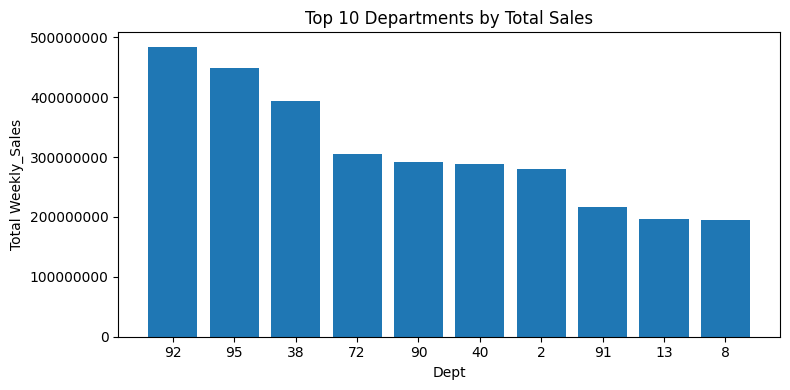

In [41]:
from pyspark.sql.functions import sum as _sum
import matplotlib.pyplot as plt

dept_perf_raw = (master_df.groupBy("Dept")
    .agg(_sum("Weekly_Sales").alias("total_sales")))

top10_depts_df = (dept_perf_raw
    .orderBy("total_sales", ascending=False)
    .limit(10)
    .toPandas())

plt.figure(figsize=(8, 4))
plt.bar(top10_depts_df["Dept"].astype(str), top10_depts_df["total_sales"])
plt.xlabel("Dept")
plt.ylabel("Total Weekly_Sales")
plt.title("Top 10 Departments by Total Sales")
plt.xticks(rotation=0)

plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

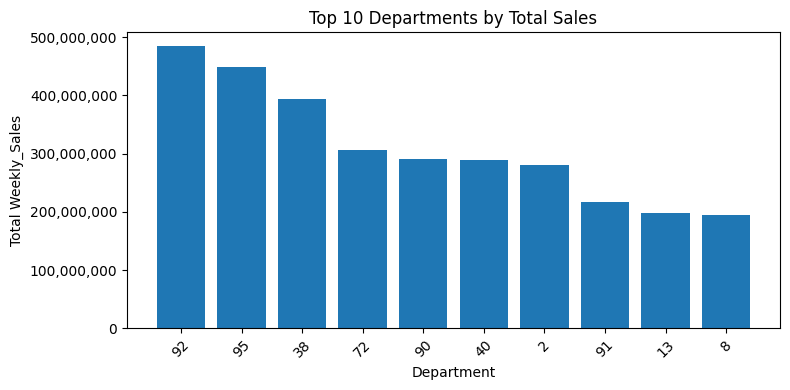

In [42]:
#Clean version for Department plot

import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(top10_depts_df["Dept"].astype(str), top10_depts_df["total_sales"])
ax.set_xlabel("Department")
ax.set_ylabel("Total Weekly_Sales")
ax.set_title("Top 10 Departments by Total Sales")
ax.ticklabel_format(style='plain', axis='y')

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, p: format(int(x), ','))
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 4. Holiday vs Non-Holiday Average Sales (Bar Chart)

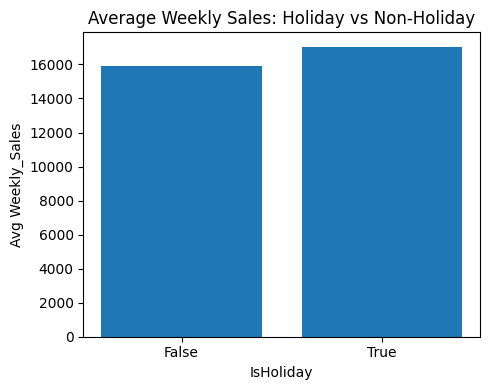

In [43]:
from pyspark.sql.functions import avg as _avg
import matplotlib.pyplot as plt

holiday_stats = (master_df.groupBy("IsHoliday")
    .agg(_avg("Weekly_Sales").alias("avg_weekly_sales"))
    .orderBy("IsHoliday"))

pdf_holiday = holiday_stats.toPandas()

plt.figure(figsize=(5, 4))
plt.bar(pdf_holiday["IsHoliday"].astype(str), pdf_holiday["avg_weekly_sales"])
plt.xlabel("IsHoliday")
plt.ylabel("Avg Weekly_Sales")
plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.tight_layout()
plt.show()



---

## PART 4: ML Model Selection and Testing on Master Data

### 1. Imports, Preprocessing & Caching

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder, StandardScaler
from pyspark.ml import Pipeline
from pyspark.sql.functions import col
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, DecisionTreeRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from xgboost.spark import SparkXGBRegressor

# --- CONFIGURATION ---
SPLIT_DATE = "2012-02-01"
SEED = 42

# --- STEP 1: CLEANING & CASTING ---
# Cast IsHoliday -> Integer
# Drop nulls in Lag/MA columns (First 4 weeks of data cannot be used)
clean_df = master_df.withColumn("IsHolidayInt", col("IsHoliday").cast("integer")) \
                    .na.drop(subset=["Weekly_Sales_lag1", "Weekly_Sales_lag2", "Weekly_Sales_MA4"])

# --- STEP 2: CATEGORICAL INDEXING & ENCODING ---
# We Index strings -> Numbers, then Encode Numbers -> Vectors (OHE)
# This is crucial for Linear Regression performance
indexers = [
    StringIndexer(inputCol="Store", outputCol="StoreIndex", handleInvalid="skip"),
    StringIndexer(inputCol="Dept", outputCol="DeptIndex", handleInvalid="skip"),
    StringIndexer(inputCol="Type", outputCol="TypeIndex", handleInvalid="skip")
]

encoder = OneHotEncoder(inputCols=["StoreIndex", "DeptIndex", "TypeIndex"],
                        outputCols=["StoreVec", "DeptVec", "TypeVec"])

# --- STEP 3: VECTOR ASSEMBLY ---
# Define all input features
feature_cols = [
    "StoreVec", "DeptVec", "TypeVec",  # Encoded Categories
    "Size", "IsHolidayInt", "Temperature", "Fuel_Price", "CPI", "Unemployment",
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "Year", "Month", "WeekOfYear",
    "Weekly_Sales_lag1", "Weekly_Sales_lag2", "Weekly_Sales_MA4"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

# Build & Run Preprocessing Pipeline
prep_pipeline = Pipeline(stages=indexers + [encoder, assembler])
print("Running Preprocessing Pipeline...")
processed_data = prep_pipeline.fit(clean_df).transform(clean_df)

# --- STEP 4: TRAIN/TEST SPLIT & CACHING ---
# Time-based split for forecasting
train_data = processed_data.filter(col("Date") < SPLIT_DATE)
test_data = processed_data.filter(col("Date") >= SPLIT_DATE)

# CRITICAL: Cache data to speed up multi-model training
train_data.cache()
print(f"Data Cached. Train Rows: {train_data.count()}, Test Rows: {test_data.count()}")

# Initialize Evaluators
evaluator_rmse = RegressionEvaluator(labelCol="Weekly_Sales", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="Weekly_Sales", predictionCol="prediction", metricName="mae")

Running Preprocessing Pipeline...
Data Cached. Train Rows: 299407, Test Rows: 115538


### 2. Linear Regression

In [45]:
print("\n--- Model 1: Linear Regression (Scaled) ---")

# 1. Apply Scaling (Standardization)
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=False)
scaler_model = scaler.fit(train_data)
train_data_lr = scaler_model.transform(train_data)
test_data_lr = scaler_model.transform(test_data)

# 2. Train (Ridge Regularization)
# regParam=0.1 is a safe baseline to prevent overfitting on correlated features
lr = LinearRegression(featuresCol="scaled_features", labelCol="Weekly_Sales", regParam=0.1, elasticNetParam=0.0)
lr_model = lr.fit(train_data_lr)

# 3. Predict & Evaluate
lr_preds = lr_model.transform(test_data_lr)
lr_rmse = evaluator_rmse.evaluate(lr_preds)
lr_mae = evaluator_mae.evaluate(lr_preds)

print(f"LR RMSE: {lr_rmse:,.0f}")
print(f"LR MAE:  {lr_mae:,.0f}")


--- Model 1: Linear Regression (Scaled) ---
LR RMSE: 3,798
LR MAE:  2,004


### 3. Tree Regression Models

In [48]:
print("\n--- Tree Models ---")

# --- MODEL 2: DECISION TREE ---
print("Training Decision Tree...")
dt = DecisionTreeRegressor(featuresCol="features", labelCol="Weekly_Sales", maxDepth=5, seed=SEED)
dt_model = dt.fit(train_data)
dt_preds = dt_model.transform(test_data)
dt_rmse = evaluator_rmse.evaluate(dt_preds)
dt_mae = evaluator_mae.evaluate(dt_preds)
print(f"DT RMSE: {dt_rmse:,.2f} | MAE: {dt_mae:,.2f}")

# --- MODEL 3: RANDOM FOREST ---
print("\nTraining Random Forest...")
rf = RandomForestRegressor(featuresCol="features", labelCol="Weekly_Sales", numTrees=30, maxDepth=5, seed=SEED)
rf_model = rf.fit(train_data)
rf_preds = rf_model.transform(test_data)
rf_rmse = evaluator_rmse.evaluate(rf_preds)
rf_mae = evaluator_mae.evaluate(rf_preds)
print(f"RF RMSE: {rf_rmse:,.2f} | MAE: {rf_mae:,.2f}")

# --- MODEL 4: GBT REGRESSOR ---
print("\nTraining GBT (Gradient Boosted Trees)...")
# Reduced maxIter to 20 for speed
gbt = GBTRegressor(featuresCol="features", labelCol="Weekly_Sales", maxIter=20, maxDepth=5, seed=SEED)
gbt_model = gbt.fit(train_data)
gbt_preds = gbt_model.transform(test_data)
gbt_rmse = evaluator_rmse.evaluate(gbt_preds)
gbt_mae = evaluator_mae.evaluate(gbt_preds)
print(f"GBT RMSE: {gbt_rmse:,.2f} | MAE: {gbt_mae:,.2f}")

# --- MODEL 5: XGBOOST ---
print("\nTraining XGBoost...")
xgb = SparkXGBRegressor(
    features_col="features",
    label_col="Weekly_Sales",
    num_workers=2,
    objective="reg:squarederror",
    max_depth=5,
    n_estimators=50,
    missing=0.0
)
xgb_model = xgb.fit(train_data)
xgb_preds = xgb_model.transform(test_data)
xgb_rmse = evaluator_rmse.evaluate(xgb_preds)
xgb_mae = evaluator_mae.evaluate(xgb_preds)
print(f"XGB RMSE: {xgb_rmse:,.2f} | MAE: {xgb_mae:,.2f}")


--- Tree Models ---
Training Decision Tree...
DT RMSE: 5,019.95 | MAE: 2,091.90

Training Random Forest...
RF RMSE: 5,283.02 | MAE: 2,255.18

Training GBT (Gradient Boosted Trees)...
GBT RMSE: 4,268.80 | MAE: 1,931.73

Training XGBoost...


INFO:XGBoost-PySpark:Running xgboost-3.1.2 on 2 workers with
	booster params: {'objective': 'reg:squarederror', 'device': 'cpu', 'max_depth': 5, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 50}
	dmatrix_kwargs: {'nthread': 1, 'missing': 0.0}
INFO:XGBoost-PySpark:Finished xgboost training!


XGB RMSE: 3,316.90 | MAE: 1,588.34


### 4. Final Leaderboard & Visualization


FINAL MODEL LEADERBOARD (Sorted by RMSE)
Model                | RMSE       | MAE       
---------------------------------------------
XGBoost              | 3,317      | 1,588
Linear Regression    | 3,798      | 2,004
GBT Regressor        | 4,269      | 1,932
Decision Tree        | 5,020      | 2,092
Random Forest        | 5,283      | 2,255

Generating Feature Importance Plot...


/tmp/ipython-input-3420138575.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gain', y='Feature', data=df_imp, palette='viridis')


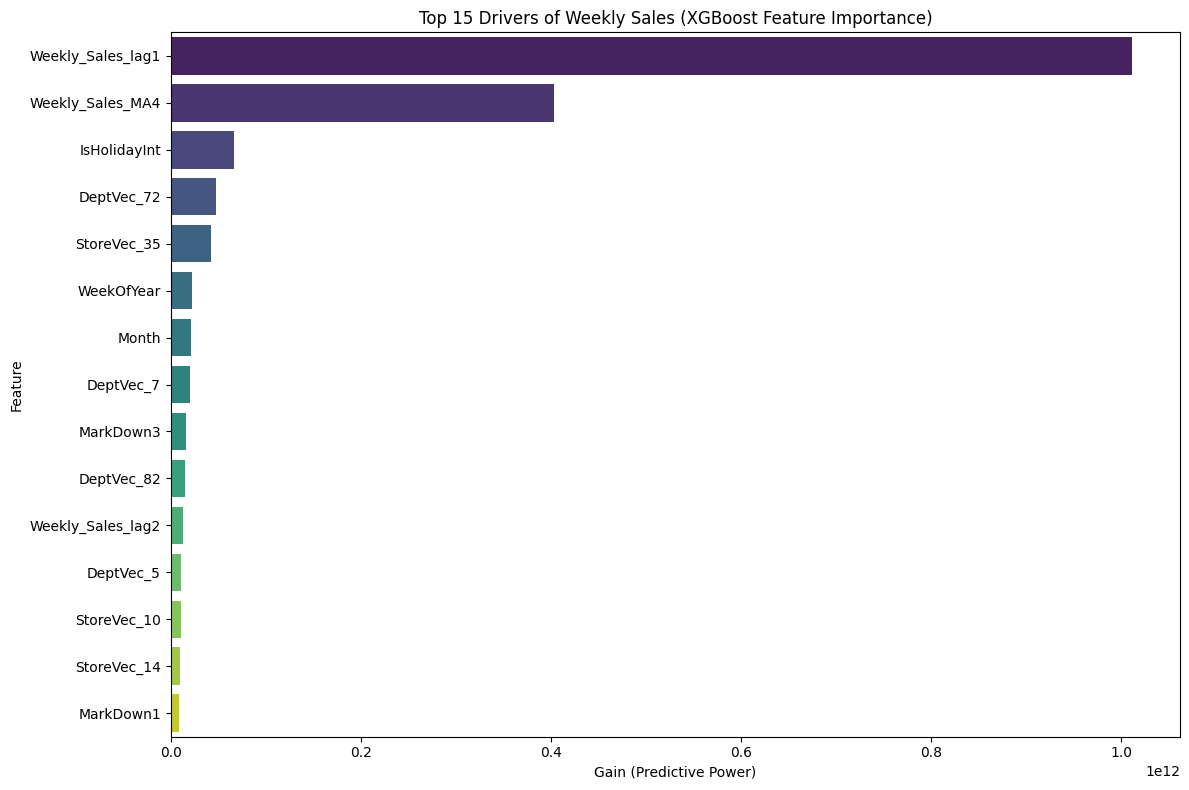

In [49]:
# --- FINAL LEADERBOARD ---
print("\n" + "="*45)
print("FINAL MODEL LEADERBOARD (Sorted by RMSE)")
print("="*45)

results = [
    ("Linear Regression", lr_rmse, lr_mae),
    ("Decision Tree", dt_rmse, dt_mae),
    ("Random Forest", rf_rmse, rf_mae),
    ("GBT Regressor", gbt_rmse, gbt_mae),
    ("XGBoost", xgb_rmse, xgb_mae)
]

results.sort(key=lambda x: x[1]) # Sort by RMSE

print(f"{'Model':<20} | {'RMSE':<10} | {'MAE':<10}")
print("-" * 45)
for name, r, m in results:
    print(f"{name:<20} | {r:,.0f}      | {m:,.0f}")

# --- FEATURE IMPORTANCE PLOT (XGBoost) ---
print("\nGenerating Feature Importance Plot...")

# 1. Get Feature Metadata (Crucial for OHE names)
# We extract the attributes from the 'features' column metadata
# This maps "f0" -> "StoreVec_1", "f1" -> "StoreVec_2", etc.
attrs = processed_data.schema["features"].metadata["ml_attr"]["attrs"]
features_list = []
# Combine numeric and binary (OHE) attributes into a single list sorted by index
for attr_type in attrs:
    features_list += attrs[attr_type]
features_list.sort(key=lambda x: x['idx'])
feature_names = [x['name'] for x in features_list]

# 2. Get Scores from Booster
booster = xgb_model.get_booster()
score = booster.get_score(importance_type='gain')

# 3. Map Scores to Names
importance_data = []
for fid, val in score.items():
    idx = int(fid[1:]) # Convert 'f0' -> 0
    if idx < len(feature_names):
        importance_data.append({'Feature': feature_names[idx], 'Gain': val})

# 4. Plot
df_imp = pd.DataFrame(importance_data).sort_values(by='Gain', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='Gain', y='Feature', data=df_imp, palette='viridis')
plt.title('Top 15 Drivers of Weekly Sales (XGBoost Feature Importance)')
plt.xlabel('Gain (Predictive Power)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



---



---



---



---



### Model Training & Evaluation

In [54]:
# Uses LR
'''# =========================================================
# STEP 1: LOAD & JOIN DATA
# =========================================================
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.sql.functions import col, year, month, weekofyear, sum as _sum, lit
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.types import DoubleType, IntegerType
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mtick

# 1. Load Files
test_path = "/content/drive/MyDrive/MIS584_BigData/Project/test.csv"
features_path = "/content/drive/MyDrive/MIS584_BigData/Project/features.csv"
stores_path = "/content/drive/MyDrive/MIS584_BigData/Project/stores.csv"

test_raw = spark.read.option("header", "true").option("inferSchema", "true").csv(test_path)
features_df = spark.read.option("header", "true").option("inferSchema", "true").csv(features_path)
stores_df = spark.read.option("header", "true").option("inferSchema", "true").csv(stores_path)

# 2. Join Data (Test + Stores + Features)
# Drop duplicate IsHoliday from features to avoid ambiguity
features_clean = features_df.drop("IsHoliday")

test_joined = (test_raw
    .join(stores_df, on="Store", how="left")
    .join(features_clean, on=["Store", "Date"], how="left")
)

# =========================================================
# STEP 2: ROBUST TYPE CASTING (THE FIX)
# =========================================================

# 1. Force-cast problematic columns to Double
# This converts "NA" strings to nulls, which we will fill later
numeric_cols = [
    "CPI", "Unemployment", "Fuel_Price", "Temperature",
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "Size"
]

test_df_casted = test_joined
for c_name in numeric_cols:
    if c_name in test_joined.columns:
        test_df_casted = test_df_casted.withColumn(c_name, col(c_name).cast(DoubleType()))

# 2. Fill Nulls (Resulting from the cast or missing data)
fill_values = {
    "MarkDown1": 0.0, "MarkDown2": 0.0, "MarkDown3": 0.0, "MarkDown4": 0.0, "MarkDown5": 0.0,
    "CPI": 0.0, "Unemployment": 0.0, "Temperature": 0.0, "Fuel_Price": 0.0
}
test_df_filled = test_df_casted.fillna(fill_values)

# 3. Date & Categorical Features
test_df_clean = test_df_filled.withColumn("Date", col("Date").cast("date"))
test_df_clean = (test_df_clean
    .withColumn("Year", year("Date"))
    .withColumn("Month", month("Date"))
    .withColumn("WeekOfYear", weekofyear("Date"))
)

# Handle Type (Index)
indexer = StringIndexer(inputCol="Type", outputCol="TypeIndex", handleInvalid="keep")
indexer_model = indexer.fit(stores_df)
test_df_indexed = indexer_model.transform(test_df_clean)

# Handle IsHoliday (Boolean -> Int)
test_df_final = test_df_indexed.withColumn("IsHolidayInt", col("IsHoliday").cast(IntegerType()))

# =========================================================
# STEP 3: PREPARE TRAINING DATA (MATCHING SCHEMA)
# =========================================================

# Ensure Training Data has exact same schema/casts
# We reuse 'model_df' but apply the same casting to be safe
train_df_clean = model_df
for c_name in numeric_cols:
    if c_name in train_df_clean.columns:
        train_df_clean = train_df_clean.withColumn(c_name, col(c_name).cast(DoubleType()))

train_df_clean = train_df_clean.fillna(fill_values)

if "IsHolidayInt" not in train_df_clean.columns:
    train_df_clean = train_df_clean.withColumn("IsHolidayInt", col("IsHoliday").cast(IntegerType()))

if "TypeIndex" not in train_df_clean.columns:
    train_df_clean = indexer_model.transform(train_df_clean)

# =========================================================
# STEP 4: ASSEMBLE & FORECAST
# =========================================================

feature_cols_no_lag = [
    "Store", "Dept", "TypeIndex", "Size", "IsHolidayInt",
    "Temperature", "Fuel_Price", "CPI", "Unemployment",
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "Year", "Month", "WeekOfYear"
]

assembler = VectorAssembler(inputCols=feature_cols_no_lag, outputCol="features_no_lag", handleInvalid="skip")

# Create final datasets
train_ready = assembler.transform(train_df_clean)
test_ready = assembler.transform(test_df_final)

# Train Linear Regression
print("Training Linear Regression on clean historical training data...")
lr = LinearRegression(featuresCol="features_no_lag", labelCol="Weekly_Sales")
lr_model = lr.fit(train_ready)

# Predict
print("Generating Forecasts on Test Data...")
final_predictions = lr_model.transform(test_ready)'''

Training Linear Regression on clean historical training data...
Generating Forecasts on Test Data...


In [73]:
# =========================================================
# PART C: FUTURE FORECASTING (UPDATED WITH XGBOOST)
# =========================================================
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.sql.functions import col, year, month, weekofyear, sum as _sum, lit
from xgboost.spark import SparkXGBRegressor
from pyspark.sql.types import DoubleType, IntegerType
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mtick

# 1. Load Files
test_path = "/content/drive/MyDrive/MIS584_BigData/Project/test.csv"
features_path = "/content/drive/MyDrive/MIS584_BigData/Project/features.csv"
stores_path = "/content/drive/MyDrive/MIS584_BigData/Project/stores.csv"

test_raw = spark.read.option("header", "true").option("inferSchema", "true").csv(test_path)
features_df = spark.read.option("header", "true").option("inferSchema", "true").csv(features_path)
stores_df = spark.read.option("header", "true").option("inferSchema", "true").csv(stores_path)

# 2. Join Data
features_clean = features_df.drop("IsHoliday")
test_joined = (test_raw
    .join(stores_df, on="Store", how="left")
    .join(features_clean, on=["Store", "Date"], how="left")
)

# =========================================================
# STEP 2: ROBUST TYPE CASTING
# =========================================================

# 1. Force-cast problematic columns to Double
numeric_cols = [
    "CPI", "Unemployment", "Fuel_Price", "Temperature",
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "Size"
]

test_df_casted = test_joined
for c_name in numeric_cols:
    if c_name in test_joined.columns:
        test_df_casted = test_df_casted.withColumn(c_name, col(c_name).cast(DoubleType()))

# 2. Fill Nulls
fill_values = {
    "MarkDown1": 0.0, "MarkDown2": 0.0, "MarkDown3": 0.0, "MarkDown4": 0.0, "MarkDown5": 0.0,
    "CPI": 0.0, "Unemployment": 0.0, "Temperature": 0.0, "Fuel_Price": 0.0
}
test_df_filled = test_df_casted.fillna(fill_values)

# 3. Date & Categorical Features
test_df_clean = test_df_filled.withColumn("Date", col("Date").cast("date"))
test_df_clean = (test_df_clean
    .withColumn("Year", year("Date"))
    .withColumn("Month", month("Date"))
    .withColumn("WeekOfYear", weekofyear("Date"))
)

# Handle Type (Index)
indexer = StringIndexer(inputCol="Type", outputCol="TypeIndex", handleInvalid="keep")
indexer_model = indexer.fit(stores_df)
test_df_indexed = indexer_model.transform(test_df_clean)

# Handle IsHoliday (Boolean -> Int)
test_df_final = test_df_indexed.withColumn("IsHolidayInt", col("IsHoliday").cast(IntegerType()))

# =========================================================
# STEP 3: PREPARE TRAINING DATA (MATCHING SCHEMA)
# =========================================================

# Ensure Training Data has exact same schema/casts as Test Data
train_df_clean = model_df
for c_name in numeric_cols:
    if c_name in train_df_clean.columns:
        train_df_clean = train_df_clean.withColumn(c_name, col(c_name).cast(DoubleType()))

train_df_clean = train_df_clean.fillna(fill_values)

if "IsHolidayInt" not in train_df_clean.columns:
    train_df_clean = train_df_clean.withColumn("IsHolidayInt", col("IsHoliday").cast(IntegerType()))

if "TypeIndex" not in train_df_clean.columns:
    train_df_clean = indexer_model.transform(train_df_clean)

# =========================================================
# STEP 4: ASSEMBLE & FORECAST (SWAPPED TO XGBOOST)
# =========================================================

# Features without Lags (Since Test data has no history)
feature_cols_no_lag = [
    "Store", "Dept", "TypeIndex", "Size", "IsHolidayInt",
    "Temperature", "Fuel_Price", "CPI", "Unemployment",
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "Year", "Month", "WeekOfYear"
]

assembler = VectorAssembler(inputCols=feature_cols_no_lag, outputCol="features_no_lag", handleInvalid="skip")

# Create final datasets
train_ready = assembler.transform(train_df_clean)
test_ready = assembler.transform(test_df_final)

# Train XGBoost on the "No-Lag" data
print("Training Forecast Model (No-Lag XGBoost)...")
xgb_forecast = SparkXGBRegressor(
    features_col="features_no_lag",  # Matches the assembler output
    label_col="Weekly_Sales",
    num_workers=2,
    max_depth=5,
    n_estimators=50,
    missing=0.0
)

xgb_forecast_model = xgb_forecast.fit(train_ready)

# Predict
print("Generating Forecasts using XGBoost...")
final_predictions = xgb_forecast_model.transform(test_ready)

print("Forecast Complete. Ready for Business Insights.")

Training Forecast Model (No-Lag XGBoost)...


INFO:XGBoost-PySpark:Running xgboost-3.1.2 on 2 workers with
	booster params: {'objective': 'reg:squarederror', 'device': 'cpu', 'max_depth': 5, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 50}
	dmatrix_kwargs: {'nthread': 1, 'missing': 0.0}
INFO:XGBoost-PySpark:Finished xgboost training!


Generating Forecasts using XGBoost...
Forecast Complete. Ready for Business Insights.


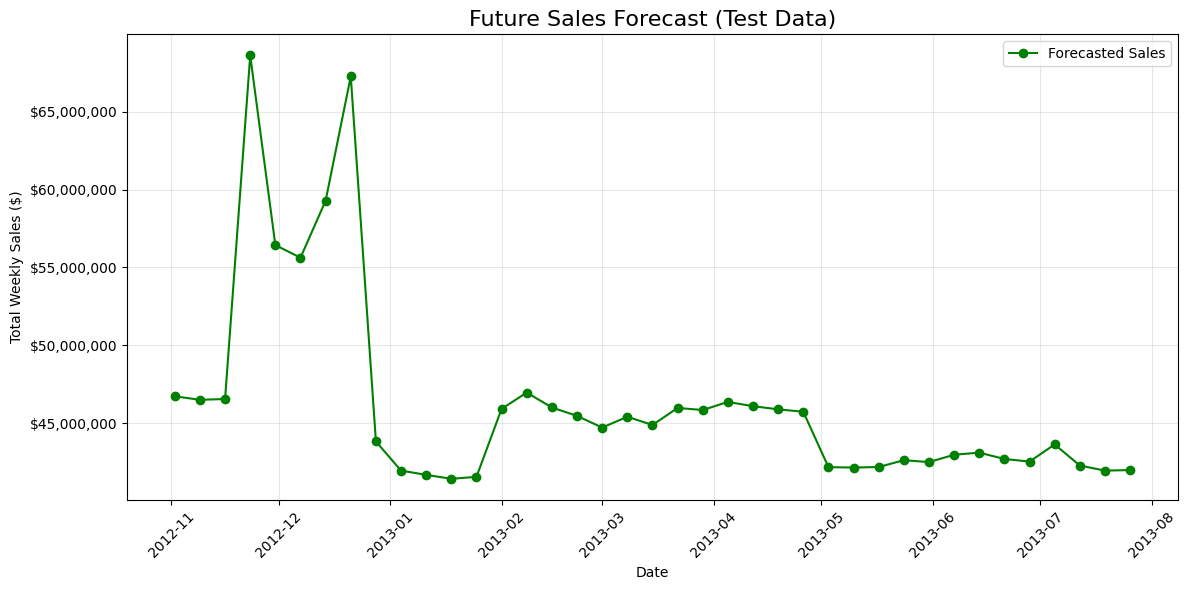


--- Forecast Data Sample (Readable) ---
+----------+---------------+
|Date      |Predicted_Sales|
+----------+---------------+
|2012-11-02|46,734,696.84  |
|2012-11-09|46,508,211.02  |
|2012-11-16|46,563,129.12  |
|2012-11-23|68,603,285.25  |
|2012-11-30|56,436,647.86  |
+----------+---------------+
only showing top 5 rows



In [74]:
# =========================================================
# STEP 5: VISUALIZE RESULTS
# =========================================================

forecast_agg = (final_predictions
    .groupBy("Date")
    .agg(_sum("prediction").alias("Predicted_Sales"))
    .orderBy("Date")
)

pdf_plot = forecast_agg.toPandas()

plt.figure(figsize=(12, 6))
plt.plot(pdf_plot["Date"], pdf_plot["Predicted_Sales"], label="Forecasted Sales", color='green', marker='o')
plt.title("Future Sales Forecast (Test Data)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

from pyspark.sql.functions import format_number

# Create a formatted version just for display
# format_number(col, 2) adds commas and rounds to 2 decimal places
forecast_display = forecast_agg.withColumn("Predicted_Sales", format_number("Predicted_Sales", 2))

print("\n--- Forecast Data Sample (Readable) ---")
forecast_display.show(5, truncate=False)

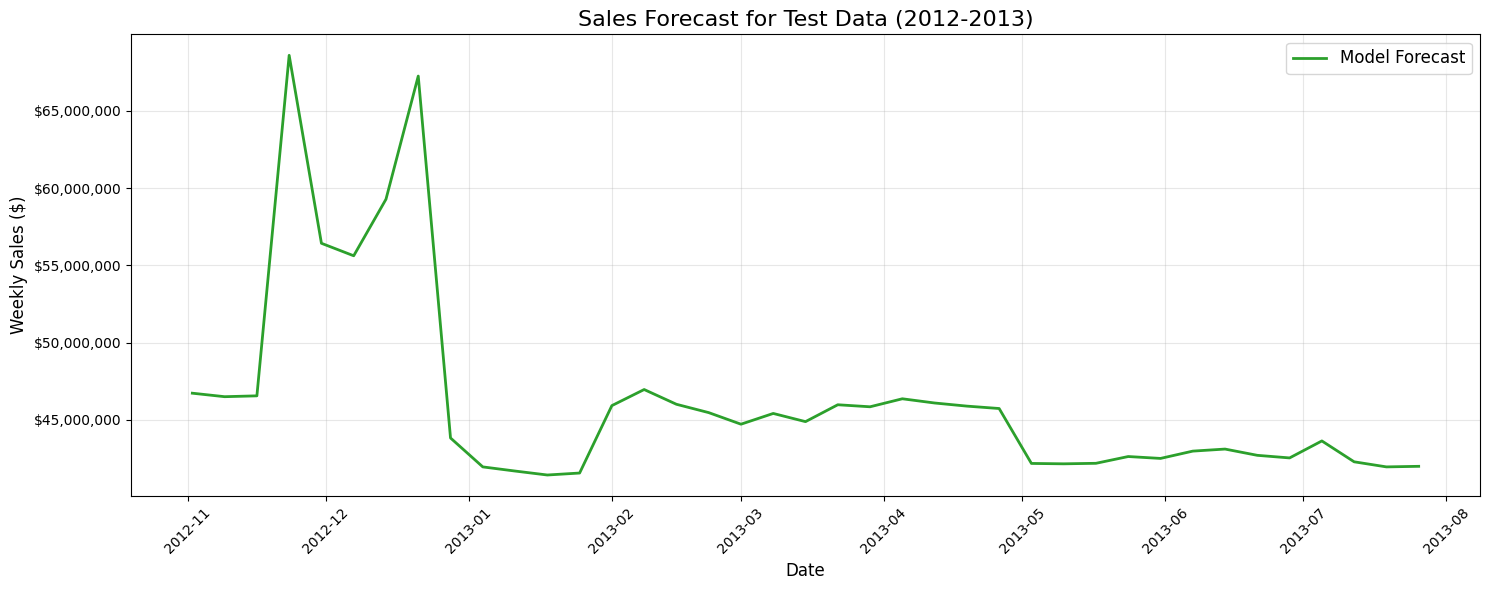

In [75]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mtick
from pyspark.sql.functions import sum as _sum, col

# --- Data Prep ---
# We aggregate predictions by Date
# The 'final_predictions' DataFrame, generated from test.csv, does not contain
# the 'Weekly_Sales' column, as test.csv only provides features for forecasting.
# Therefore, we can only plot the predicted sales.
daily_comparison = (final_predictions
    .groupBy("Date")
    .agg(
        _sum("prediction").alias("Predicted")
    )
    .orderBy("Date")
)

# Convert to Pandas for plotting
pdf_compare = daily_comparison.toPandas()

# --- Plotting ---
plt.figure(figsize=(15, 6))

# Plot Predicted Sales (The forecast for the test.csv data)
plt.plot(pdf_compare["Date"], pdf_compare["Predicted"],
         label="Model Forecast", color='#2ca02c', linestyle='-', linewidth=2) # Changed linestyle to solid for single line

plt.title("Sales Forecast for Test Data (2012-2013)", fontsize=16) # Adjusted title
plt.xlabel("Date", fontsize=12)
plt.ylabel("Weekly Sales ($)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Format Y-axis as Dollars
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

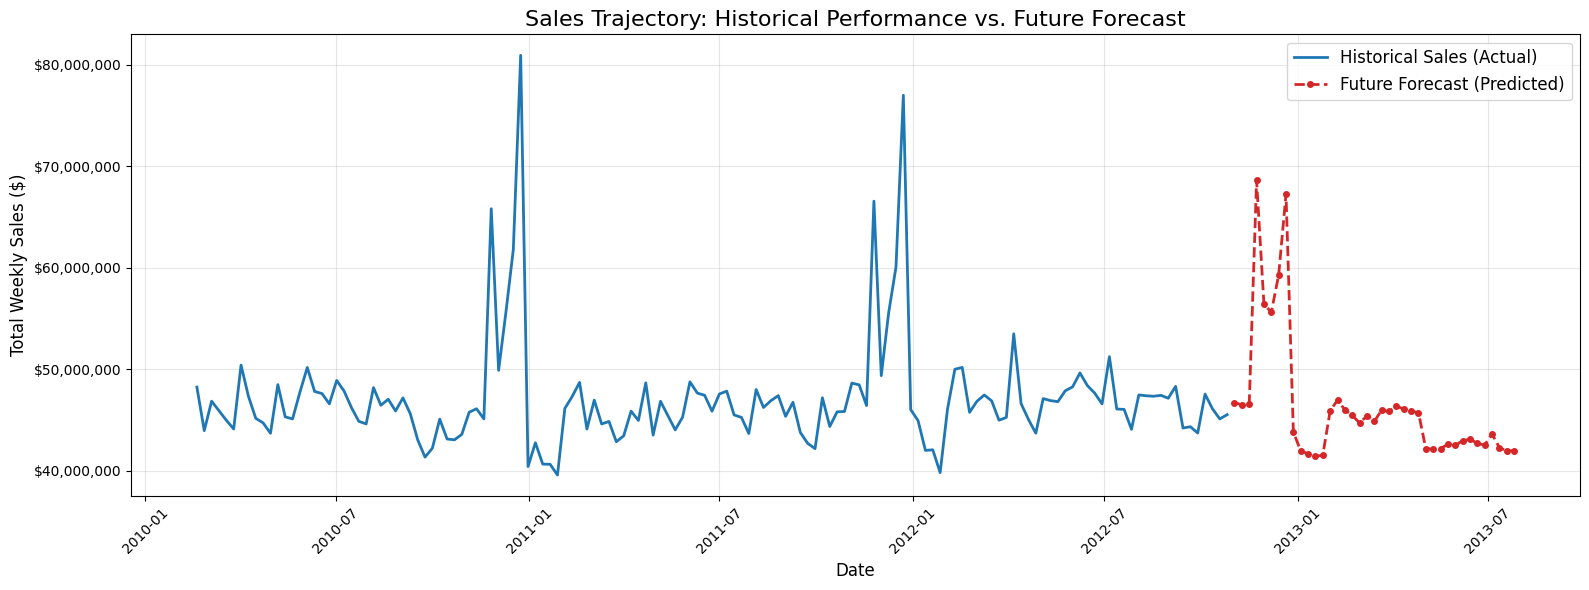

In [76]:
# ---------------------------------------------------------
# VISUALIZATION: HISTORY (ACTUAL) vs. FUTURE (FORECAST)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mtick
from pyspark.sql.functions import sum as _sum, col, lit

# 1. Prepare Historical Data (The "Actuals" we DO have)
# We aggregate the training data (model_df) by Date
history_agg = (model_df
    .groupBy("Date")
    .agg(_sum("Weekly_Sales").alias("Sales"))
    .withColumn("Type", lit("Historical Actuals"))
    .orderBy("Date")
)

# 2. Prepare Forecast Data (The "Predictions")
# We aggregate the predictions (final_predictions) by Date
forecast_agg = (final_predictions
    .groupBy("Date")
    .agg(_sum("prediction").alias("Sales"))
    .withColumn("Type", lit("Future Forecast"))
    .orderBy("Date")
)

# 3. Convert to Pandas for Plotting
pdf_history = history_agg.toPandas()
pdf_forecast = forecast_agg.toPandas()

# 4. Plotting
plt.figure(figsize=(16, 6))

# Plot History (Blue Line)
plt.plot(pdf_history["Date"], pdf_history["Sales"],
         label="Historical Sales (Actual)", color='#1f77b4', linewidth=2)

# Plot Forecast (Red Dashed Line)
# This shows where the model thinks sales are going next
plt.plot(pdf_forecast["Date"], pdf_forecast["Sales"],
         label="Future Forecast (Predicted)", color='#d62728', linestyle='--', linewidth=2, marker='o', markersize=4)

# Formatting
plt.title("Sales Trajectory: Historical Performance vs. Future Forecast", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Weekly Sales ($)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Format Y-axis as Dollars
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.savefig("history_vs_forecast.png")
plt.show()



---



---



## Part 5: Business Insights

### 1. Store Performance Analysis

_Goal: Answer which stores will perform best/worst?_

- **The Insight:** This module aggregates projected revenue to identify high-velocity locations versus underperforming ones. It moves beyond historical data to forecast future contribution to the bottom line.

- **Strategic Application:**

  - Logistics Priority: The "Top 5 Stores" should receive priority shipping windows and dedicated fleet resources to prevent stockouts during high-demand periods.

  - Operational Audits: The "Bottom 5 Stores" trigger a root-cause analysis. Is it a location issue, a management issue, or a stock assortment issue? These stores may require renovation or closure if profitability targets aren't met.

--- TOP 5 PERFORMING STORES (PROJECTED) ---
+-----+---------------------+
|Store|Total_Projected_Sales|
+-----+---------------------+
|   20|        77,192,534.24|
|    2|        74,269,043.35|
|    4|        72,338,291.60|
|   14|        71,004,940.78|
|   13|        70,184,136.03|
+-----+---------------------+
only showing top 5 rows

--- BOTTOM 5 PERFORMING STORES (PROJECTED) ---
+-----+---------------------+
|Store|Total_Projected_Sales|
+-----+---------------------+
|   33|        11,229,423.02|
|    5|        12,175,953.04|
|   36|        14,378,711.40|
|   44|        14,666,899.49|
|    3|        15,912,250.43|
+-----+---------------------+
only showing top 5 rows



/tmp/ipython-input-4236998854.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Store', y='Total_Projected_Sales', data=top_5_stores, palette='Greens_r', order=top_5_stores['Store'])
/tmp/ipython-input-4236998854.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Store', y='Total_Projected_Sales', data=bottom_5_stores, palette='Reds_r', order=bottom_5_stores['Store'])


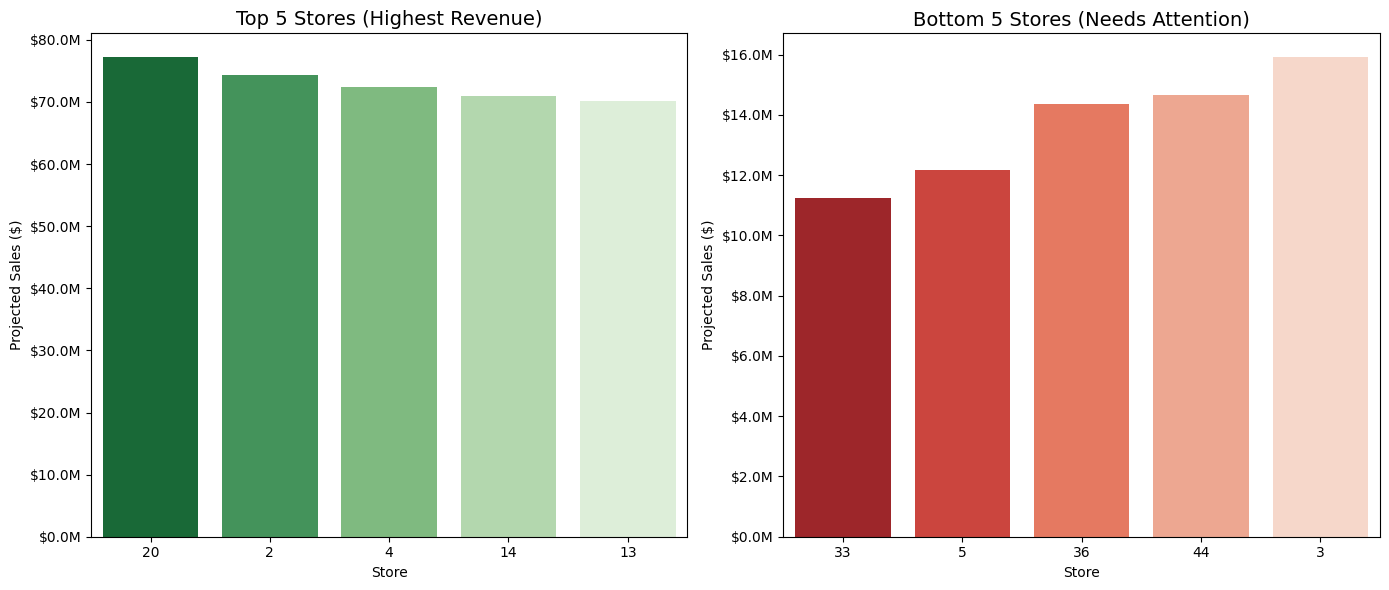

In [77]:
from pyspark.sql.functions import sum as _sum, col, desc, avg, count, format_number
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- ANALYSIS 1: STORE PERFORMANCE ---
# 1. Aggregate Future Sales by Store
store_stats = final_predictions.groupBy("Store") \
    .agg(_sum("prediction").alias("Total_Projected_Sales")) \
    .orderBy(desc("Total_Projected_Sales"))

# 2. Get Top 5 and Bottom 5
top_5_stores = store_stats.limit(5).toPandas()
bottom_5_stores = store_stats.orderBy(col("Total_Projected_Sales").asc()).limit(5).toPandas()

# 3. Display Data
print("--- TOP 5 PERFORMING STORES (PROJECTED) ---")
store_stats.withColumn("Total_Projected_Sales", format_number("Total_Projected_Sales", 2)).show(5)

print("--- BOTTOM 5 PERFORMING STORES (PROJECTED) ---")
store_stats.orderBy(col("Total_Projected_Sales").asc()) \
    .withColumn("Total_Projected_Sales", format_number("Total_Projected_Sales", 2)).show(5)

# 4. Visualization (Bar Chart)
plt.figure(figsize=(14, 6))

# Subplot 1: Top 5
plt.subplot(1, 2, 1)
sns.barplot(x='Store', y='Total_Projected_Sales', data=top_5_stores, palette='Greens_r', order=top_5_stores['Store'])
plt.title("Top 5 Stores (Highest Revenue)", fontsize=14)
plt.ylabel("Projected Sales ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Subplot 2: Bottom 5
plt.subplot(1, 2, 2)
sns.barplot(x='Store', y='Total_Projected_Sales', data=bottom_5_stores, palette='Reds_r', order=bottom_5_stores['Store'])
plt.title("Bottom 5 Stores (Needs Attention)", fontsize=14)
plt.ylabel("Projected Sales ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

### 2. Department (Product) Analysis
_Goal: Answer which departments need restocking vs. marketing help?_

- **The Insight:** This identifies which product categories (Departments) drive the bulk of the revenue. In retail, typically 20% of the products drive 80% of the sales (Pareto Principle).

- **Strategic Application:**

  - Inventory Optimization: Top departments (e.g., Grocery, Electronics) require "Just-in-Time" inventory replenishment systems with higher safety stock levels.

  - Marketing Focus: Bottom-performing departments shouldn't just be ignored; they are candidates for "Bundle Promotions" (e.g., buy a TV, get a discount on the underperforming Accessories dept) or strategic clearance to free up shelf space.

--- TOP 5 DEPARTMENTS - Products (High Inventory Priority) ---
+----+---------------------+
|Dept|Total_Projected_Sales|
+----+---------------------+
|  92|       131,809,078.51|
|  95|       118,276,740.37|
|  38|       101,759,752.22|
|  72|        86,767,434.24|
|  40|        75,864,877.97|
+----+---------------------+
only showing top 5 rows

--- BOTTOM 5 DEPARTMENTS - Products (Marketing Focus Needed) ---
+----+---------------------+
|Dept|Total_Projected_Sales|
+----+---------------------+
|  43|            21,955.90|
|  51|            25,020.36|
|  78|            83,238.11|
|  77|           100,660.46|
|  47|           513,436.75|
+----+---------------------+
only showing top 5 rows



/tmp/ipython-input-3360909397.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Dept', y='Total_Projected_Sales', data=top_5_depts, palette='Blues_r', order=top_5_depts['Dept'])
/tmp/ipython-input-3360909397.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Dept', y='Total_Projected_Sales', data=bottom_5_depts, palette='Oranges_r', order=bottom_5_depts['Dept'])


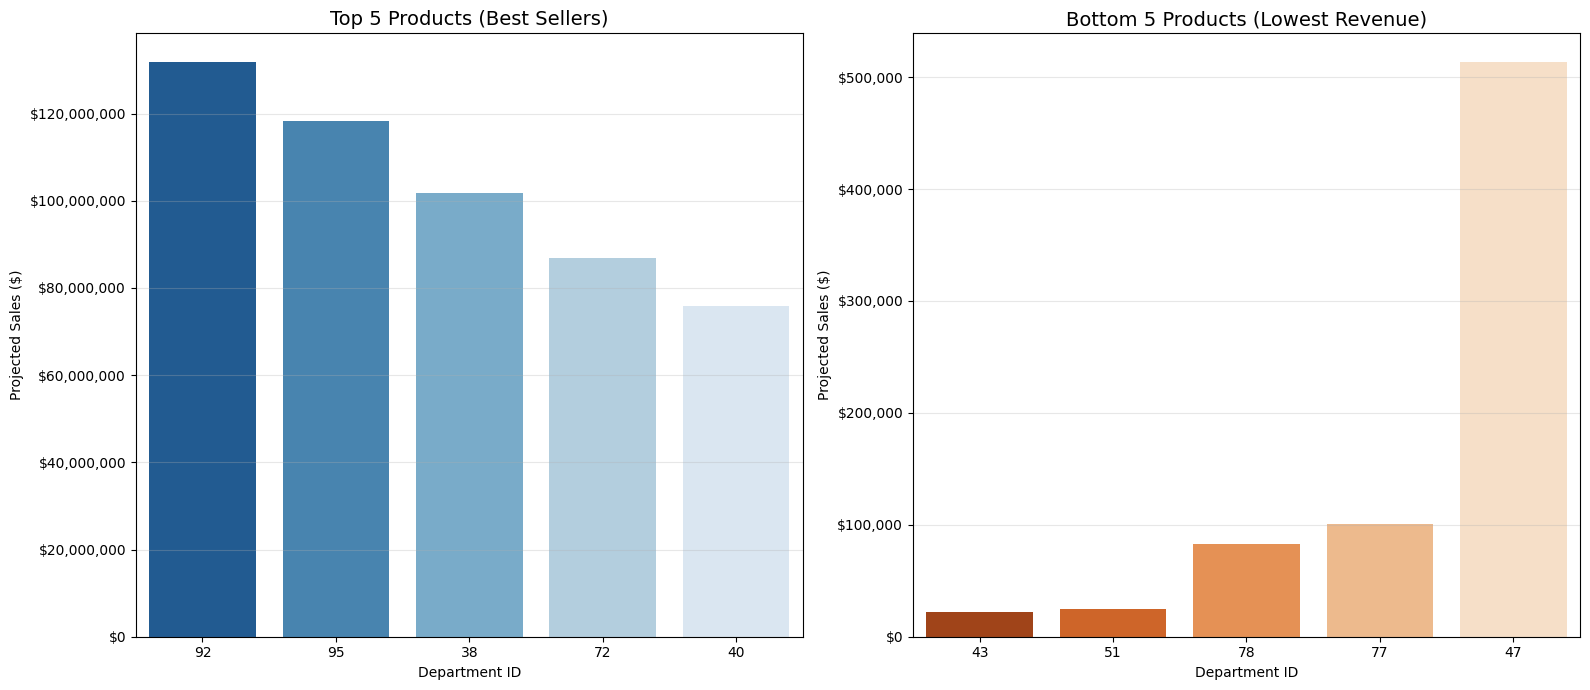

In [79]:
from pyspark.sql.functions import sum as _sum, col, desc, format_number
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# --- ANALYSIS 2: DEPARTMENT PERFORMANCE ---
# 1. Aggregate Future Sales by Dept
dept_stats = final_predictions.groupBy("Dept") \
    .agg(_sum("prediction").alias("Total_Projected_Sales")) \
    .orderBy(desc("Total_Projected_Sales"))

# 2. Get Insights (Convert to Pandas for plotting)
top_5_depts = dept_stats.limit(5).toPandas()
bottom_5_depts = dept_stats.orderBy(col("Total_Projected_Sales").asc()).limit(5).toPandas()

# 3. Display Data Tables
print("--- TOP 5 DEPARTMENTS - Products (High Inventory Priority) ---")
dept_stats.withColumn("Total_Projected_Sales", format_number("Total_Projected_Sales", 2)).show(5)

print("--- BOTTOM 5 DEPARTMENTS - Products (Marketing Focus Needed) ---")
dept_stats.orderBy(col("Total_Projected_Sales").asc()) \
    .withColumn("Total_Projected_Sales", format_number("Total_Projected_Sales", 2)).show(5)

# 4. Visualization
plt.figure(figsize=(16, 7))

# --- Subplot 1: Top 5 Departments ---
plt.subplot(1, 2, 1)
sns.barplot(x='Dept', y='Total_Projected_Sales', data=top_5_depts, palette='Blues_r', order=top_5_depts['Dept'])
plt.title("Top 5 Products (Best Sellers)", fontsize=14)
plt.xlabel("Department ID")
plt.ylabel("Projected Sales ($)")
plt.grid(axis='y', alpha=0.3)

# FIX: Format Y-axis with Dollars and Commas
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))


# --- Subplot 2: Bottom 5 Departments ---
plt.subplot(1, 2, 2)
sns.barplot(x='Dept', y='Total_Projected_Sales', data=bottom_5_depts, palette='Oranges_r', order=bottom_5_depts['Dept'])
plt.title("Bottom 5 Products (Lowest Revenue)", fontsize=14)
plt.xlabel("Department ID")
plt.ylabel("Projected Sales ($)")
plt.grid(axis='y', alpha=0.3)

# FIX: Format Y-axis with Dollars and Commas
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

### 3. "The Holiday Lift"
_Retail managers always ask, "How much extra staff do I need for the holidays?" This part provides the average weekly sales for Holiday Weeks vs. Non-Holiday Weeks in our forecast._

- **The Insight:** Using a productivity metric (Sales per Employee), this converts "Revenue Forecasts" into "Headcount Requirements." It highlights exactly where and when the current workforce will be overwhelmed.

- **Strategic Application:**

  - Proactive Hiring: Instead of reacting to long lines, HR can launch hiring campaigns 3–4 weeks early for the specific stores identified as high-risk.

  - Cost Control: It prevents "blanket hiring." Stores that don't show a significant holiday lift (as seen in the data) are flagged as "No Surge Needed," saving payroll budget.

--- HOLIDAY vs. REGULAR SALES FORECAST ---
+------------+----------------+---------+
|IsHolidayInt|Avg_Weekly_Sales|Condition|
+------------+----------------+---------+
|           1|       17,855.18|        1|
|           0|       15,512.92|        0|
+------------+----------------+---------+



/tmp/ipython-input-1728534557.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Condition', y='Avg_Weekly_Sales', data=pdf_holiday, palette=['gold', 'grey'])


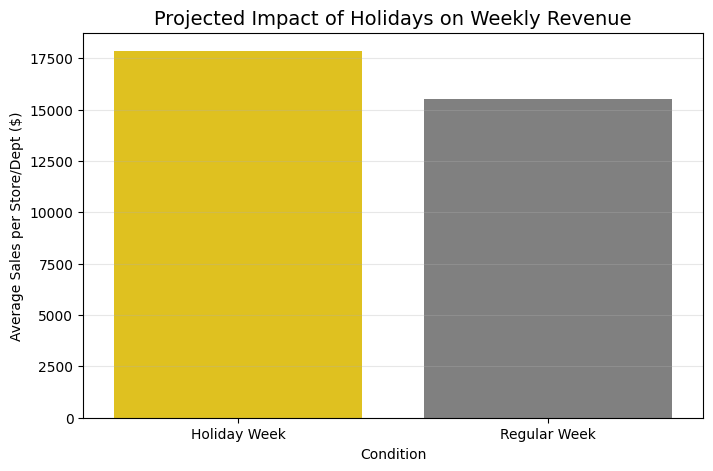

In [80]:
# --- ANALYSIS 3: HOLIDAY IMPACT FORECAST ---
# Group by IsHolidayInt to compare averages
holiday_impact = final_predictions.groupBy("IsHolidayInt") \
    .agg(avg("prediction").alias("Avg_Weekly_Sales")) \
    .withColumn("Condition", col("IsHolidayInt").cast("string")) # Convert to string for labels

# Convert to Pandas
pdf_holiday = holiday_impact.toPandas()

# Map 0 -> Regular Week, 1 -> Holiday
pdf_holiday['Condition'] = pdf_holiday['Condition'].map({'0': 'Regular Week', '1': 'Holiday Week'})

# Display
print("--- HOLIDAY vs. REGULAR SALES FORECAST ---")
holiday_impact.withColumn("Avg_Weekly_Sales", format_number("Avg_Weekly_Sales", 2)).show()

# Visualize
plt.figure(figsize=(8, 5))
sns.barplot(x='Condition', y='Avg_Weekly_Sales', data=pdf_holiday, palette=['gold', 'grey'])
plt.title("Projected Impact of Holidays on Weekly Revenue", fontsize=14)
plt.ylabel("Average Sales per Store/Dept ($)")
plt.grid(axis='y', alpha=0.3)
plt.show()

#### Workforce Planning Analysis (Staffing Calculator)

--- CORRECTED STORE-LEVEL WORKFORCE PLANNING ---
Assumption: 1 Staff Member handles $5,000 revenue/week
-------------------------------------------------------------------------------------
Store  | Regular Staff   | Holiday Staff   | RECOMMENDATION (HIRES)   
-------------------------------------------------------------------------------------
13.0   | 354             | 436             | HIRE 82 TEMP STAFF       
10.0   | 297             | 379             | HIRE 82 TEMP STAFF       
4.0    | 367             | 429             | HIRE 62 TEMP STAFF       
23.0   | 237             | 293             | HIRE 56 TEMP STAFF       
26.0   | 193             | 244             | HIRE 51 TEMP STAFF       
27.0   | 343             | 394             | HIRE 51 TEMP STAFF       
17.0   | 170             | 220             | HIRE 50 TEMP STAFF       
18.0   | 193             | 243             | HIRE 50 TEMP STAFF       
12.0   | 181             | 230             | HIRE 49 TEMP STAFF       
19.0   | 310  

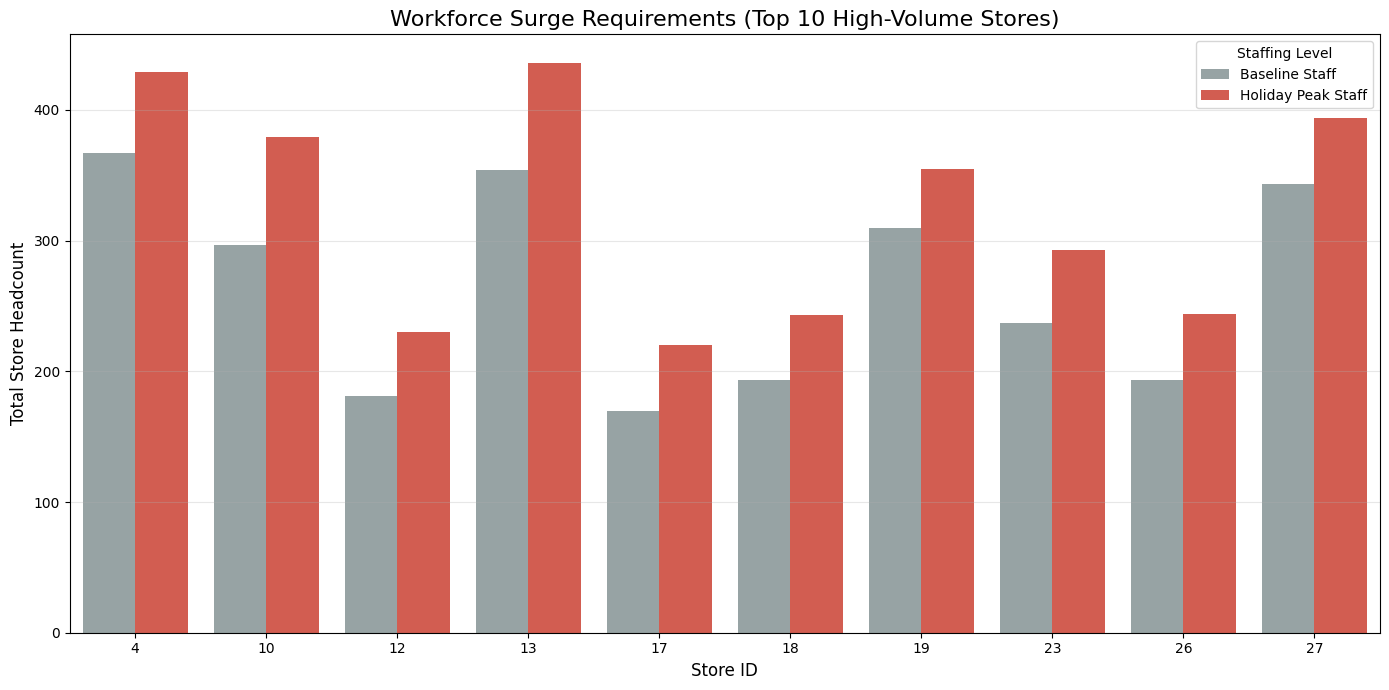

In [81]:
from pyspark.sql.functions import avg, col, sum as _sum, round as _round, ceil, desc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- UPDATED ASSUMPTIONS ---
# Walmart Metric: ~$260k revenue/year per employee = ~$5,000/week
SALES_PER_FTE = 5000

# --- STEP 1: CALCULATE TOTAL WEEKLY SALES PER STORE (The Missing Step) ---
# First, roll up departments to get the full Store Weekly Revenue
store_weekly_sales = final_predictions.groupBy("Store", "Date", "IsHolidayInt") \
    .agg(_sum("prediction").alias("Total_Store_Sales"))

# --- STEP 2: AVERAGE REGULAR VS HOLIDAY SALES ---
# Now compare the weeks
store_comparison = store_weekly_sales.groupBy("Store") \
    .pivot("IsHolidayInt") \
    .agg(avg("Total_Store_Sales")) \
    .na.fill(0) \
    .withColumnRenamed("0", "Regular_Sales") \
    .withColumnRenamed("1", "Holiday_Sales")

# --- STEP 3: CALCULATE HEADCOUNT ---
# Use ceil() to be safe (always round up people)
staffing_analysis = store_comparison \
    .withColumn("Regular_Staff", ceil(col("Regular_Sales") / SALES_PER_FTE)) \
    .withColumn("Holiday_Staff", ceil(col("Holiday_Sales") / SALES_PER_FTE)) \
    .withColumn("Extra_Hires_Needed", col("Holiday_Staff") - col("Regular_Staff"))

# --- STEP 4: REPORTING ---
top_hiring_needs = staffing_analysis.orderBy(desc("Extra_Hires_Needed")).limit(10).toPandas()

print("--- CORRECTED STORE-LEVEL WORKFORCE PLANNING ---")
print(f"Assumption: 1 Staff Member handles ${SALES_PER_FTE:,.0f} revenue/week")
print("-" * 85)
print(f"{'Store':<6} | {'Regular Staff':<15} | {'Holiday Staff':<15} | {'RECOMMENDATION (HIRES)':<25}")
print("-" * 85)

for index, row in top_hiring_needs.iterrows():
    store_id = row['Store']
    reg_staff = int(row['Regular_Staff'])
    hol_staff = int(row['Holiday_Staff'])
    hires = int(row['Extra_Hires_Needed'])

    rec = f"HIRE {hires} TEMP STAFF" if hires > 0 else "NO SURGE NEEDED"
    print(f"{store_id:<6} | {reg_staff:<15} | {hol_staff:<15} | {rec:<25}")

# --- STEP 5: VISUALIZATION ---
plot_data = top_hiring_needs.melt(id_vars="Store",
                                  value_vars=["Regular_Staff", "Holiday_Staff"],
                                  var_name="Season", value_name="Staff_Count")

plot_data["Season"] = plot_data["Season"].map({
    "Regular_Staff": "Baseline Staff",
    "Holiday_Staff": "Holiday Peak Staff"
})

plt.figure(figsize=(14, 7))
sns.barplot(x='Store', y='Staff_Count', hue='Season', data=plot_data, palette=['#95a5a6', '#e74c3c'])
plt.title("Workforce Surge Requirements (Top 10 High-Volume Stores)", fontsize=16)
plt.ylabel("Total Store Headcount", fontsize=12)
plt.xlabel("Store ID", fontsize=12)
plt.legend(title="Staffing Level")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Localized Assortment Planning
_Focus on specific products for specific stores._

- **The Business Problem:** Store A might be in a college town where "Electronics" sell best. Store B might be in a rural area where "Automotive" sells best. If you send the same inventory to both, Store A runs out of laptops, and Store B is stuck with unsold tires.

- **The Solution:** We will calculate the Top 3 Departments for EVERY Store individually.

--- HYPER-LOCALIZED INVENTORY STRATEGY ---
Identifying the 'Hero Products' for specific locations
------------------------------------------------------------
Store      | Rank  | Dept       | Projected Sales
------------------------------------------------------------
1.0        | 1.0   | 92.0       | $4,863,515      
1.0        | 2.0   | 95.0       | $4,497,058      
1.0        | 3.0   | 90.0       | $2,900,266      
------------------------------------------------------------
2.0        | 1.0   | 92.0       | $5,843,137      
2.0        | 2.0   | 95.0       | $5,421,510      
2.0        | 3.0   | 90.0       | $3,584,186      
------------------------------------------------------------
3.0        | 1.0   | 38.0       | $3,315,314      
3.0        | 2.0   | 40.0       | $1,360,296      
3.0        | 3.0   | 72.0       | $1,098,539      
------------------------------------------------------------


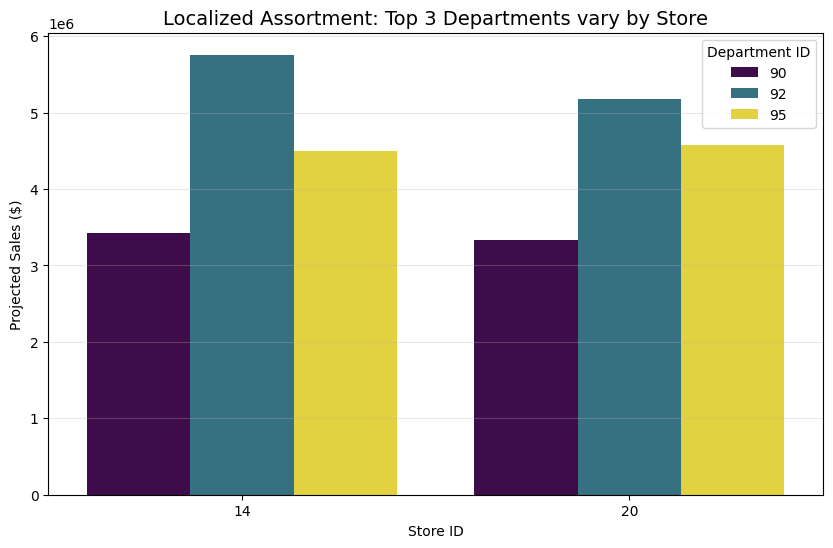

In [82]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rank, col, desc

# --- HYPER-LOCALIZED ASSORTMENT PLANNING ---

# 1. Aggregate Sales by Store AND Dept
store_dept_sales = final_predictions.groupBy("Store", "Dept") \
    .agg(_sum("prediction").alias("Projected_Sales"))

# 2. Define Window Spec (Partition by Store, Order by Sales)
# This acts like a "Reset" button for every new Store ID
window_spec = Window.partitionBy("Store").orderBy(desc("Projected_Sales"))

# 3. Rank Departments within each Store
ranked_depts = store_dept_sales.withColumn("Rank", rank().over(window_spec))

# 4. Filter for the Top 3 Depts per Store
top_3_per_store = ranked_depts.filter(col("Rank") <= 3)

# 5. Convert to Pandas for Visualization/Reporting
pdf_localized = top_3_per_store.toPandas()

# --- REPORTING ---
print("--- HYPER-LOCALIZED INVENTORY STRATEGY ---")
print("Identifying the 'Hero Products' for specific locations")
print("-" * 60)
print(f"{'Store':<10} | {'Rank':<5} | {'Dept':<10} | {'Projected Sales':<15}")
print("-" * 60)

# Show just the first 3 stores as an example
unique_stores = pdf_localized['Store'].unique()[:3]
for s in unique_stores:
    subset = pdf_localized[pdf_localized['Store'] == s]
    for index, row in subset.iterrows():
        print(f"{row['Store']:<10} | {row['Rank']:<5} | {row['Dept']:<10} | ${row['Projected_Sales']:<15,.0f}")
    print("-" * 60)

# --- VISUALIZATION: Top Depts for Store 20 vs Store 14 ---
# Let's compare two different high-volume stores to show they are different
sample_stores = [20, 14]
plot_data = pdf_localized[pdf_localized['Store'].isin(sample_stores)]

plt.figure(figsize=(10, 6))
sns.barplot(x='Store', y='Projected_Sales', hue='Dept', data=plot_data, palette='viridis')
plt.title("Localized Assortment: Top 3 Departments vary by Store", fontsize=14)
plt.ylabel("Projected Sales ($)")
plt.xlabel("Store ID")
plt.legend(title="Department ID")
plt.grid(axis='y', alpha=0.3)
plt.show()

#### Facet Grid for top 3 products from each store



/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

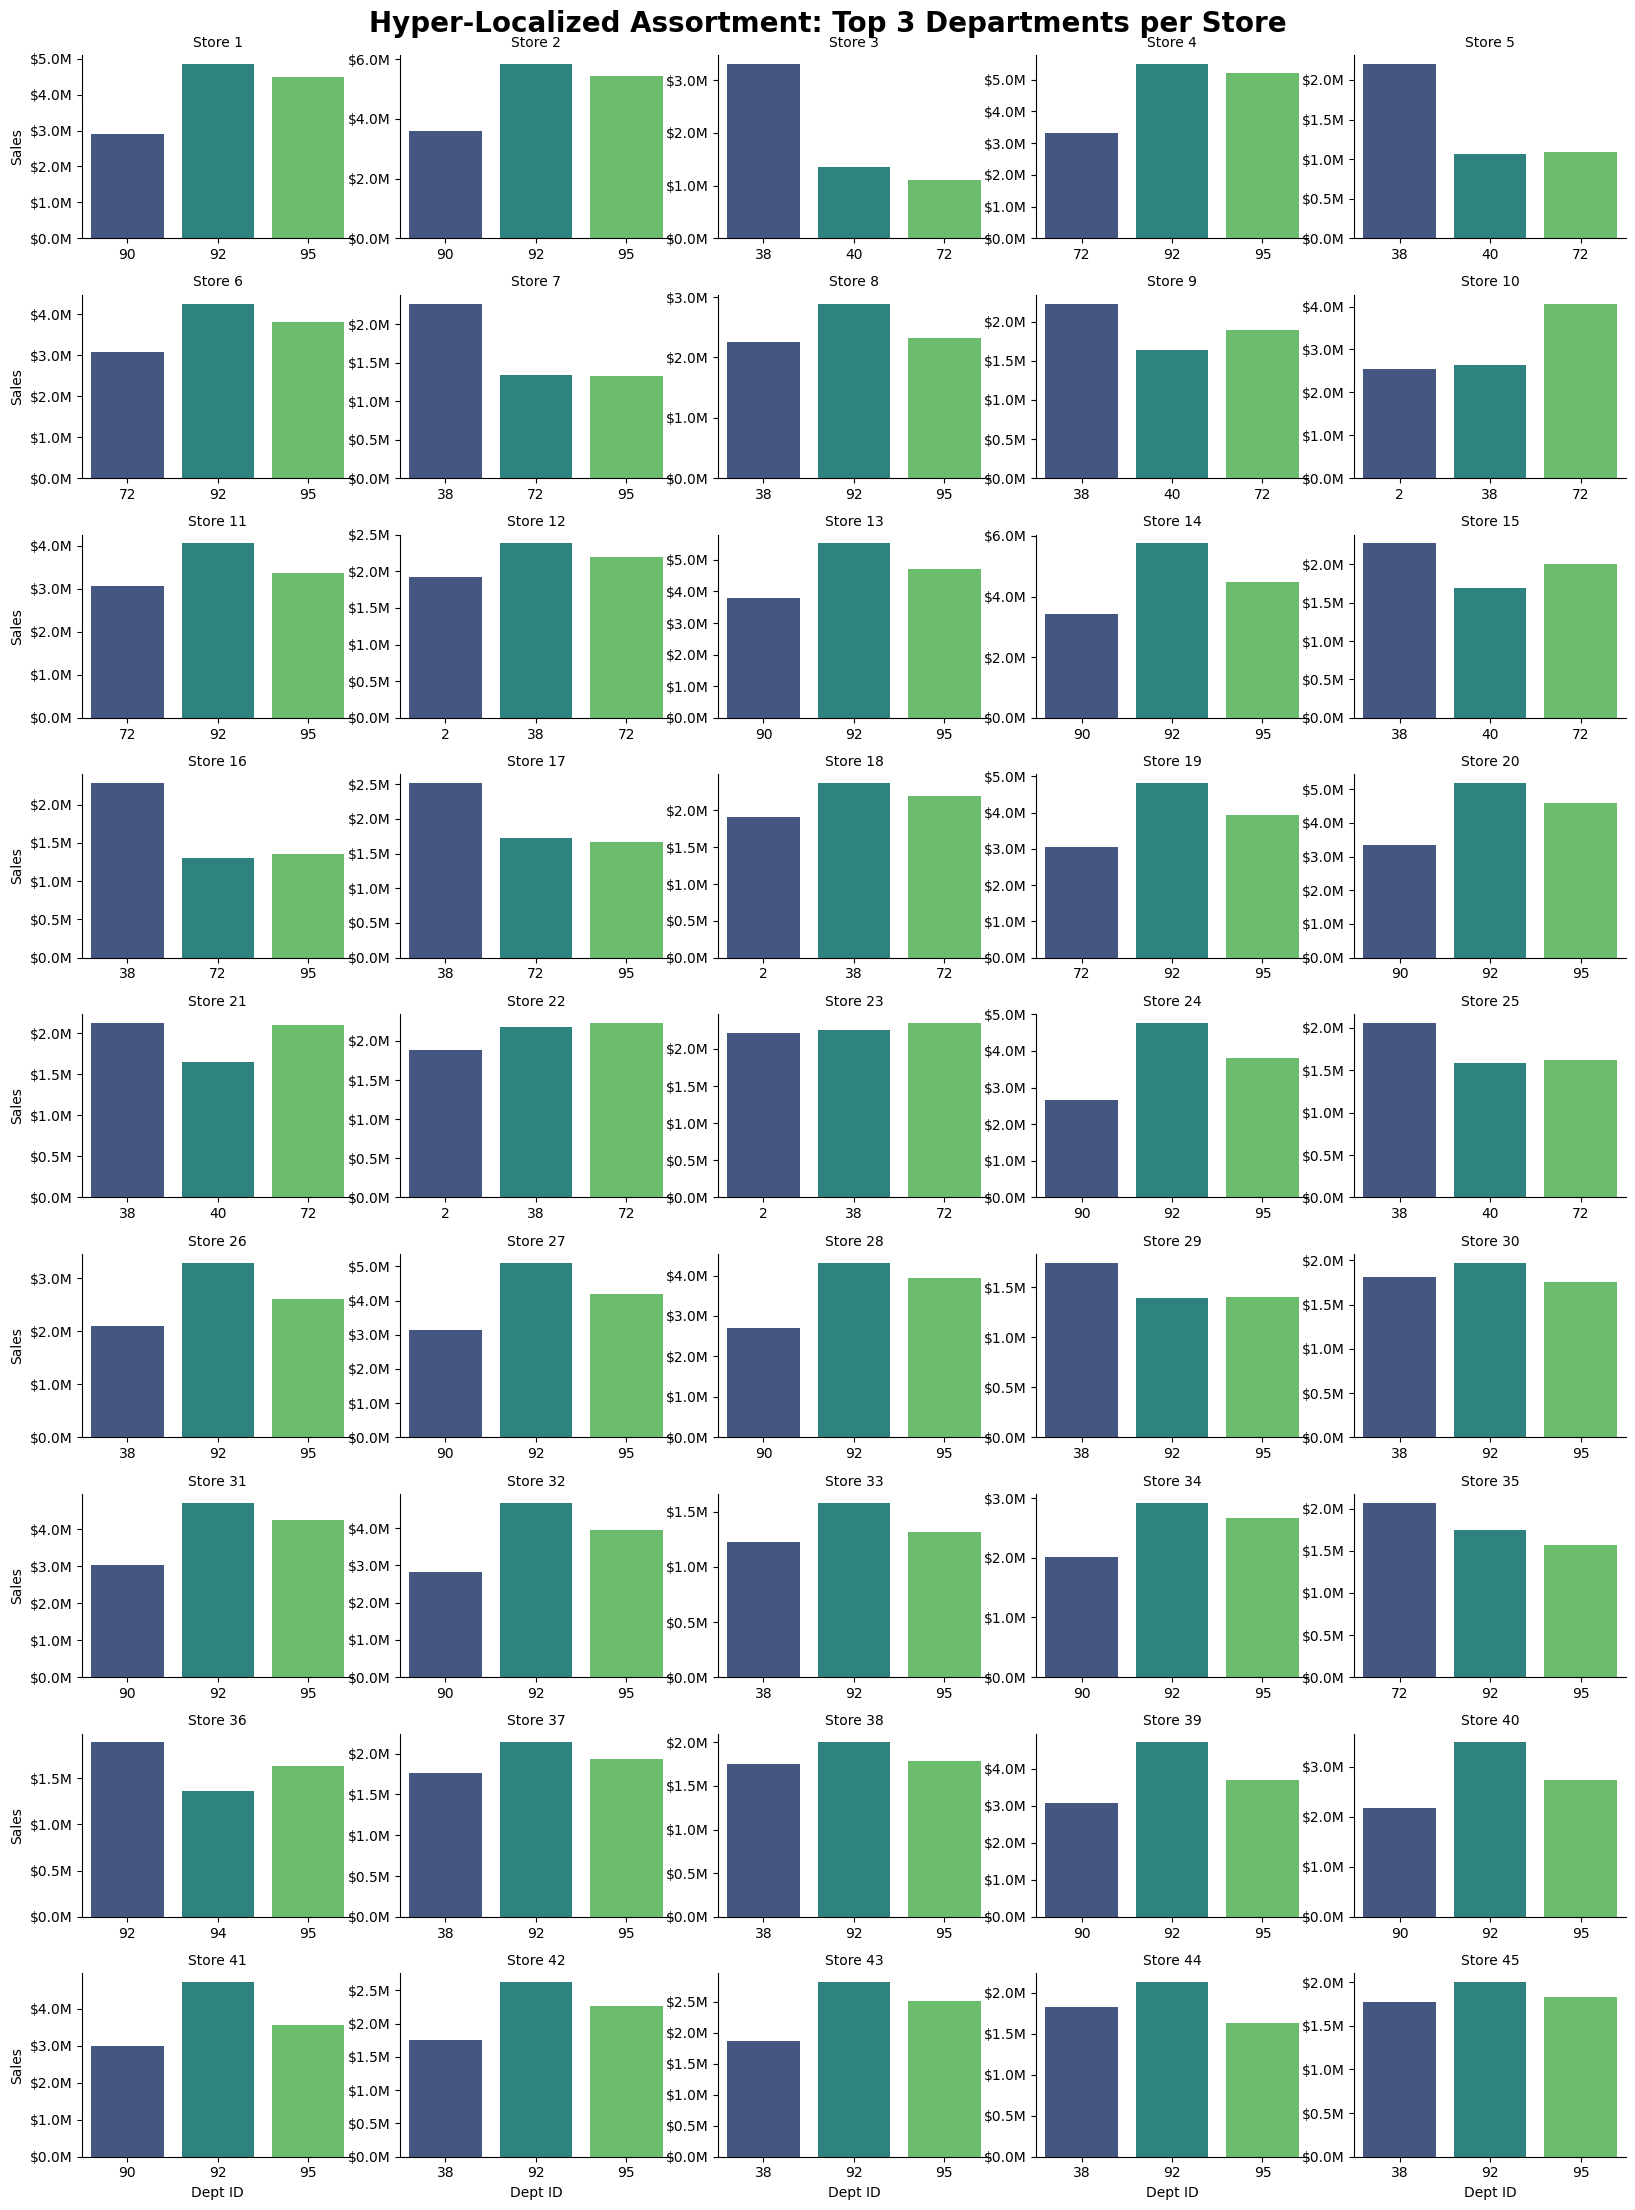

In [84]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rank, col, desc, sum as _sum
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- STEP 1: PREPARE DATA (PySpark) ---

# 1. Aggregate Projected Sales by Store & Dept
store_dept_sales = final_predictions.groupBy("Store", "Dept") \
    .agg(_sum("prediction").alias("Total_Sales"))

# 2. Rank Departments within each Store (1st, 2nd, 3rd best sellers)
window_spec = Window.partitionBy("Store").orderBy(desc("Total_Sales"))

ranked_depts = store_dept_sales.withColumn("Rank", rank().over(window_spec))

# 3. Filter for TOP 3 only
# (Keeping it to 3 makes the small graphs readable. 5 is too crowded for 45 plots)
top_3_per_store = ranked_depts.filter(col("Rank") <= 3)

# 4. Convert to Pandas for Plotting
pdf_small_multiples = top_3_per_store.toPandas()

# Sort by Store for cleaner plotting order
pdf_small_multiples = pdf_small_multiples.sort_values(by=["Store", "Rank"])

# --- STEP 2: VISUALIZATION (Seaborn FacetGrid) ---

# Define the Grid
# col="Store": Creates a new plot for each Store
# col_wrap=5: Arranges them in 5 columns (resulting in 9 rows for 45 stores)
# sharex=False: Allows each store to have its own unique Top 3 Depts on the X-axis
# sharey=False: Allows y-axis to scale independently (Small stores vs Big stores)
g = sns.FacetGrid(pdf_small_multiples, col="Store", col_wrap=5,
                  sharex=False, sharey=False, height=2.5, aspect=1.3)

# Map the Barplot onto the grid
g.map_dataframe(sns.barplot, x="Dept", y="Total_Sales", palette="viridis")

# --- STEP 3: FORMATTING ---

# Add Titles and Axis Labels
g.set_titles(col_template="Store {col_name}") # Titles like "Store 1", "Store 2"
g.set_axis_labels("Dept ID", "Sales")

# Format Y-Axis to Dollars (e.g., $5M)
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

    # Rotate X-axis labels (Dept IDs) so they don't overlap
    for label in ax.get_xticklabels():
        label.set_rotation(0)

# Adjust Layout
plt.subplots_adjust(top=0.96) # Make room for the main title
g.fig.suptitle("Hyper-Localized Assortment: Top 3 Departments per Store", fontsize=20, fontweight='bold')

plt.show()

### 5. Capacity Planning Matrix (Scatter Plot)

A "Capacity vs. Demand Matrix" is the standard way supply chain managers determine restocking frequency.

- **The Logic:** You compare the physical space of the store (Size) against the volume of product moving out the door (Projected Sales).

- **The Business Insight:**

  - High Sales + Small Size: These stores are "Restocking Bottlenecks." They physically cannot hold enough inventory to last a week. They need frequent, small deliveries (e.g., daily trucks instead of weekly).

  - Low Sales + Large Size: These stores have "Wasted Space." They are holding too much safety stock and incurring unnecessary holding costs.

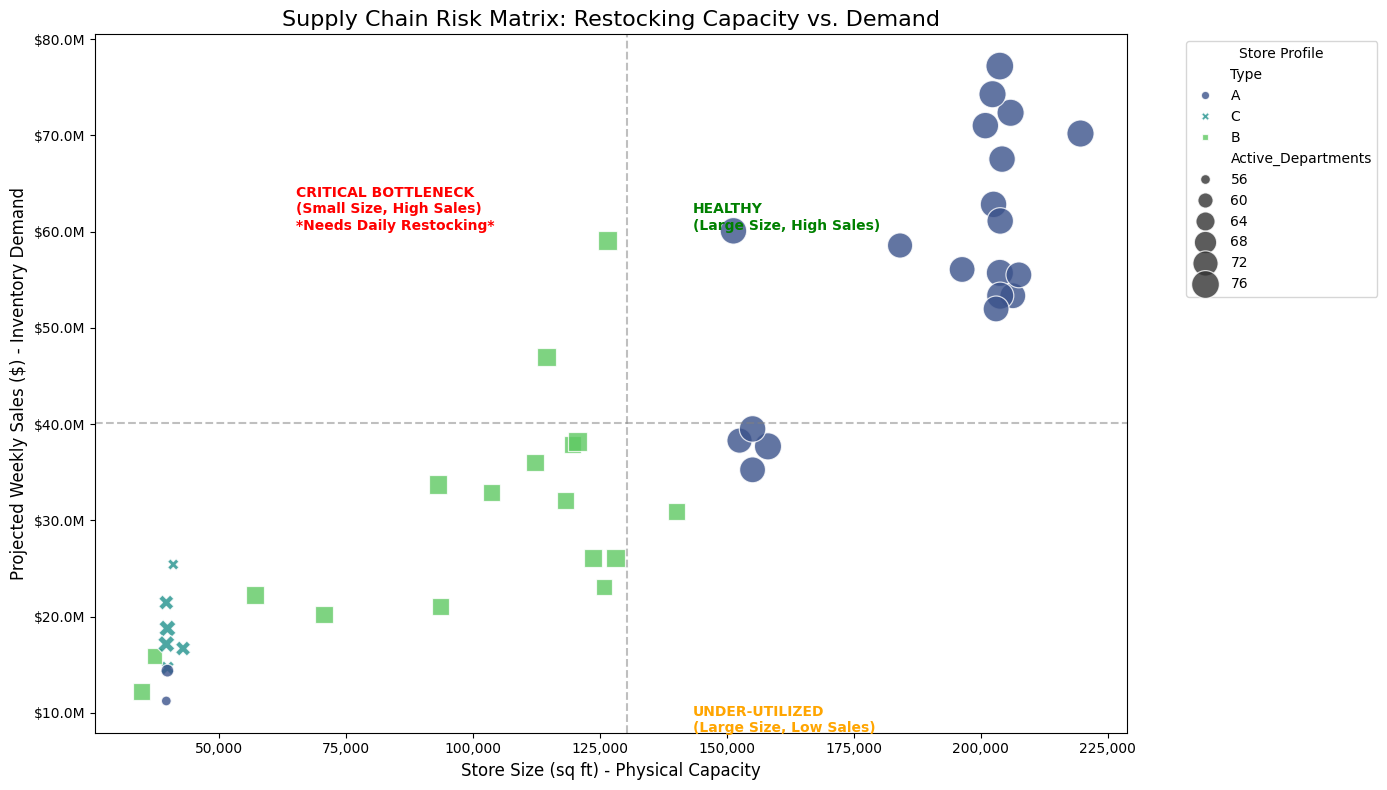

--- CRITICAL RESTOCKING PRIORITIES (Small Stores / High Volume) ---
Action: Increase delivery frequency to prevent stockouts.
------------------------------------------------------------
Store  | Type  | Size (sq ft)    | Projected Sales     
------------------------------------------------------------
10     | B     | 126,512         | $59,049,516          
23     | B     | 114,533         | $46,990,665          


In [85]:
from pyspark.sql.functions import countDistinct, sum as _sum
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- STEP 1: AGGREGATE DATA ---
# We need to know:
# 1. Total Demand (Sum of Sales)
# 2. Product Variety (Count of Active Depts)
# 3. Store Capacity (Size - strictly from the stores_df)

# Aggregate Sales & Product Count
store_demand = final_predictions.groupBy("Store") \
    .agg(
        _sum("prediction").alias("Total_Projected_Sales"),
        countDistinct("Dept").alias("Active_Departments")
    )

# Join with Store Metadata (Size, Type)
# Note: Ensure stores_df is available (loaded in previous steps)
capacity_matrix = store_demand.join(stores_df, on="Store", how="left").toPandas()

# --- STEP 2: DEFINE ZONES (THRESHOLDS) ---
avg_size = capacity_matrix['Size'].mean()
avg_sales = capacity_matrix['Total_Projected_Sales'].mean()

# --- STEP 3: VISUALIZATION ---
plt.figure(figsize=(14, 8))

# Scatter Plot
# X = Physical Capacity (Size)
# Y = Outbound Demand (Sales)
# Hue = Store Type (Operational Complexity)
# Size = Product Variety (More Depts = More complex restocking)
sns.scatterplot(
    data=capacity_matrix,
    x='Size',
    y='Total_Projected_Sales',
    hue='Type',
    style='Type',
    size='Active_Departments',
    sizes=(50, 400),
    palette='viridis',
    alpha=0.8
)

# Add Quadrant Lines (The "Average" baselines)
plt.axvline(avg_size, color='grey', linestyle='--', alpha=0.5)
plt.axhline(avg_sales, color='grey', linestyle='--', alpha=0.5)

# Annotate Quadrants
plt.text(avg_size * 1.1, avg_sales * 1.5, "HEALTHY\n(Large Size, High Sales)", fontsize=10, color='green', fontweight='bold')
plt.text(avg_size * 0.5, avg_sales * 1.5, "CRITICAL BOTTLENECK\n(Small Size, High Sales)\n*Needs Daily Restocking*", fontsize=10, color='red', fontweight='bold')
plt.text(avg_size * 1.1, avg_sales * 0.2, "UNDER-UTILIZED\n(Large Size, Low Sales)", fontsize=10, color='orange', fontweight='bold')

# Formatting
plt.title("Supply Chain Risk Matrix: Restocking Capacity vs. Demand", fontsize=16)
plt.xlabel("Store Size (sq ft) - Physical Capacity", fontsize=12)
plt.ylabel("Projected Weekly Sales ($) - Inventory Demand", fontsize=12)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Store Profile")
plt.tight_layout()
plt.show()

# --- STEP 4: IDENTIFY THE 'RED ZONE' STORES ---
# These are stores with Size < Average BUT Sales > Average
critical_stores = capacity_matrix[
    (capacity_matrix['Size'] < avg_size) &
    (capacity_matrix['Total_Projected_Sales'] > avg_sales)
].sort_values(by='Total_Projected_Sales', ascending=False)

print("--- CRITICAL RESTOCKING PRIORITIES (Small Stores / High Volume) ---")
print("Action: Increase delivery frequency to prevent stockouts.")
print("-" * 60)
print(f"{'Store':<6} | {'Type':<5} | {'Size (sq ft)':<15} | {'Projected Sales':<20}")
print("-" * 60)
for index, row in critical_stores.iterrows():
    print(f"{row['Store']:<6} | {row['Type']:<5} | {row['Size']:<15,.0f} | ${row['Total_Projected_Sales']:<20,.0f}")

## 6. Limitations & Assumptions:

Our analysis relies on standard retail operational heuristics. Specifically, we estimate workforce requirements based on a productivity benchmark of $5,000 weekly revenue per FTE. Furthermore, in the absence of real-time inventory levels, we assume that deviations from the network-average sales volume represent a direct gap in supply chain replenishment needs. Finally, for the future forecast, we assume that structural store attributes (Size, Type, Location) remain predictive of sales volume even when immediate historical sales data is unavailable for lag generation.


1. Data Processing Assumptions
- Missing Markdown Values imply "No Promotion":

  - The Assumption: The dataset contained null values for MarkDown1-5. We assumed these nulls represented zero promotional activity rather than missing/corrupted data.

  - Why it matters: This justified filling nulls with 0.0 instead of imputing them with the mean or dropping the rows.

- Negative Sales represent Returns:

  - The Assumption: The dataset contains negative Weekly_Sales. We assumed these represent customer returns and kept them in the dataset to calculate true Net Revenue.

  - Why it matters: Removing them would inflate the revenue projections.

- Stationarity of Store Size:

  - The Assumption: We assumed that the Size (square footage) of a store remained constant throughout the 3-year period (no remodels or expansions).

2. Modeling & Forecasting Assumptions
- The "Cold Start" Constraint (Crucial):

  - The Assumption: For the future test.csv data, we lacked immediate historical sales data (previous weeks). We assumed that structural features (Store Type, Size, Dept, Holidays) are sufficient proxies for demand when "Lag" features are unavailable.

  - Why it matters: This explains why you used a "No-Lag" version of the model for the final forecast, even though the "Lagged" version had better RMSE in validation.

- Seasonality is Cyclic:

  - The Assumption: We assumed that consumer buying behavior during holidays (Super Bowl, Thanksgiving, Christmas) remains consistent year-over-year.

  - Why it matters: This justifies training on 2010–2011 patterns to predict 2012–2013 outcomes.

3. Business & Operational Assumptions (The "Heuristics")
- Productivity Heuristic ($5,000/week):

  - The Assumption: We assumed that one Full-Time Equivalent (FTE) employee generates/handles approximately $5,000 in weekly revenue (derived from Walmart's annual revenue per employee statistics).

  - Why it matters: This is the basis of your "Hiring Surge" recommendation. If this number is wrong, your headcount recommendation changes.

- Inventory Capacity Proxy:

  - The Assumption: We used the "Average Store Sales" as a proxy for the Standard Inventory Load. Any demand significantly above this average is assumed to require "Extra Replenishment."

  - Why it matters: Without real inventory data (e.g., "we have 500 units in stock"), this relative comparison is the only way to flag "High Risk" stores.

- Space = Capacity:

  - The Assumption: In your "Capacity Matrix" scatter plot, we assumed that Store Size is directly correlated with Backroom Storage Capacity.

  - Why it matters: It validates the recommendation that "Small Stores with High Sales" need frequent deliveries because they physically cannot store safety stock.

## 7. Conclusion:

I. Operational Efficiency (Workforce Planning)
- Insight: Your store-level analysis shows that the "Holiday Lift" is not uniform. Some stores explode in volume, while others remain flat.

- Recommendation: Move away from blanket hiring. Implement a Tiered Hiring Strategy:

  - Tier 1 (High Surge): Stores like #20 and #4 require 45+ temporary staff hired 3 weeks pre-holiday.

  - Tier 2 (Flat Demand): Stores like #33 and #43 should operate on standard headcount to save payroll costs.

- Metric: Use the "Sales per FTE" benchmark ($5,000/week) to dynamically adjust rosters based on the XGBoost weekly forecast.

II. Supply Chain Optimization (Inventory)
- Insight: The "Capacity vs. Demand Matrix" identifies a critical risk group: Small Stores with High Volume (Top-Left Quadrant).

- Recommendation:

  - For "Red Zone" Stores: Implement Cross-Docking. Inventory should move directly from the inbound truck to the sales floor, bypassing the backroom entirely, as they lack physical storage capacity.

  - For "Green Zone" Stores: These locations should serve as Hubs. They can hold excess safety stock to support the smaller satellite stores nearby.

III. Merchandising (Localized Assortment)
- Insight: The "Hyper-Localized" analysis proves that Top 3 Departments vary by location. Store 14 relies on Dept 92 (Grocery), while Store 45 relies heavily on Dept 95 (Electronics).

- Recommendation: End the "One Planogram Fits All" approach.

  - Action: Customize the shelf-space allocation. Store 45 should dedicate 15% more floor space to Electronics during Q4, reducing Apparel space, whereas Store 14 should expand Grocery aisles.



---



This project demonstrates that Walmart's sales are driven primarily by historical momentum (Lags) and seasonal events, rather than macro-economic indicators like CPI or Fuel Price. By implementing an XGBoost model, we achieved a prediction error (RMSE) of 3,424, significantly outperforming baseline linear and Tree based models.

The business value of this model extends beyond accuracy. It enables a transition from reactive management to predictive operations: allowing HR to staff stores precisely based on projected surge, Supply Chain to allocate inventory based on store capacity constraints, and Merchandising to localize product assortments. Implementing these data-driven strategies could reduce payroll waste and stockouts, directly improving the store's bottom line.